# CSE457 • XỬ LÝ ÂM THANH VÀ TIẾNG NÓI
## LAB 1: PHÂN TÍCH VÀ XỬ LÝ TÍN HIỆU ÂM THANH SỐ
**Từ tín hiệu rời rạc đến FFT/STFT, lọc số, lượng tử hóa và mã hóa âm thanh**

---
### Thông tin sinh viên:
- **Họ và tên**: Nguyễn Thị Nam Phương
- **Mã sinh viên**: 2351260682
- **Mã lớp học phần**: CSE457
- **Thời lượng**: 03 tiết thực hành
---

### 0. Khởi tạo môi trường, cài đặt hiển thị và định nghĩa đường dẫn

In [1]:
import os
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
from pydub import AudioSegment

# Thiết lập đồ thị hiển thị chuyên nghiệp
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.5

# Thư mục tài nguyên
AUDIO_DIR = 'audio'
FIG_DIR = 'figures'
os.makedirs(AUDIO_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

SPEECH_FILE = os.path.join(AUDIO_DIR, 'speech_input.wav')
MUSIC_FILE = os.path.join(AUDIO_DIR, 'music_input.wav')

print('Môi trường và cấu hình đã khởi tạo thành công!')

Môi trường và cấu hình đã khởi tạo thành công!


---
## KHỐI A: ĐỌC VÀ KIỂM TRA DỮ LIỆU ÂM THANH
**Mục tiêu**:
1. Đọc tệp âm thanh (WAV/MP3), trích xuất metadata: tần số lấy mẫu $F_s$, số kênh (*channels*), thời lượng (*duration*), định dạng mẫu (*subtype/bit depth*), dung lượng tệp.
2. Nếu là stereo, chuyển đổi sang mono bằng cách lấy trung bình 2 kênh: $x_{mono}[n] = \frac{x_L[n] + x_R[n]}{2}$.
3. So sánh năng lượng RMS giữa 2 kênh và bản mono.
4. Chuẩn hóa biên độ tín hiệu về miền $[-1, 1]$ để xử lý số học chính xác.

In [2]:
def read_and_inspect_audio(filepath, label):
    fsize = os.path.getsize(filepath)
    info = sf.info(filepath)
    data, sr = sf.read(filepath, dtype='float64')
    
    # Tách kênh trái, phải và tính mono
    if data.ndim > 1 and data.shape[1] == 2:
        left = data[:, 0]
        right = data[:, 1]
        mono = (left + right) / 2.0
    else:
        left = data
        right = data
        mono = data
        
    # Chuẩn hóa về [-1, 1] nếu cần
    max_abs = np.max(np.abs(mono))
    if max_abs > 1.0:
        mono = mono / max_abs
        left = left / np.max(np.abs(left))
        right = right / np.max(np.abs(right))
        
    rms_l = np.sqrt(np.mean(left**2))
    rms_r = np.sqrt(np.mean(right**2))
    rms_mono = np.sqrt(np.mean(mono**2))
    peak = np.max(np.abs(mono))
    
    print(f'=== {label} ===')
    print(f'  - Đường dẫn tệp: {filepath}')
    print(f'  - Dung lượng tệp: {fsize:,} bytes ({fsize/(1024*1024):.3f} MB)')
    print(f'  - Tần số lấy mẫu (Fs): {sr:,} Hz')
    print(f'  - Số kênh: {info.channels} (Stereo)')
    print(f'  - Thời lượng: {info.duration:.3f} s ({len(mono):,} mẫu)')
    print(f'  - Định dạng/Độ rộng mẫu: {info.subtype}')
    print(f'  - Peak mono: {peak:.5f} ({20*np.log10(peak):.2f} dBFS)')
    print(f'  - RMS Trái:  {rms_l:.5f} ({20*np.log10(rms_l):.2f} dBFS)')
    print(f'  - RMS Phải:  {rms_r:.5f} ({20*np.log10(rms_r):.2f} dBFS)')
    print(f'  - RMS Mono:  {rms_mono:.5f} ({20*np.log10(rms_mono):.2f} dBFS)\n')
    return mono, sr, info

speech_mono, sr_speech, info_speech = read_and_inspect_audio(SPEECH_FILE, 'TỆP TIẾNG NÓI (SPEECH)')
music_mono, sr_music, info_music = read_and_inspect_audio(MUSIC_FILE, 'TỆP ÂM NHẠC (MUSIC)')

=== TỆP TIẾNG NÓI (SPEECH) ===
  - Đường dẫn tệp: audio\speech_input.wav
  - Dung lượng tệp: 2,617,820 bytes (2.497 MB)
  - Tần số lấy mẫu (Fs): 44,100 Hz
  - Số kênh: 2 (Stereo)
  - Thời lượng: 14.840 s (654,444 mẫu)
  - Định dạng/Độ rộng mẫu: PCM_16
  - Peak mono: 0.81030 (-1.83 dBFS)
  - RMS Trái:  0.11209 (-19.01 dBFS)
  - RMS Phải:  0.11209 (-19.01 dBFS)
  - RMS Mono:  0.11209 (-19.01 dBFS)

=== TỆP ÂM NHẠC (MUSIC) ===
  - Đường dẫn tệp: audio\music_input.wav
  - Dung lượng tệp: 8,087,084 bytes (7.712 MB)
  - Tần số lấy mẫu (Fs): 44,100 Hz
  - Số kênh: 2 (Stereo)
  - Thời lượng: 45.845 s (2,021,760 mẫu)
  - Định dạng/Độ rộng mẫu: PCM_16
  - Peak mono: 0.78564 (-2.10 dBFS)
  - RMS Trái:  0.07247 (-22.80 dBFS)
  - RMS Phải:  0.07247 (-22.80 dBFS)
  - RMS Mono:  0.07247 (-22.80 dBFS)



**Nhận xét kỹ thuật Khối A**:
1. Cả hai tệp đều có tần số lấy mẫu chuẩn phòng thu $F_s = 44,100\text{ Hz}$, độ rộng mẫu 16-bit nguyên (`PCM_16`). Dải tần số Nyquist bảo toàn đạt tới $F_{Nyquist} = 22,050\text{ Hz}$, bao phủ toàn bộ ngưỡng nghe của tai người ($20\text{ Hz} - 20,000\text{ Hz}$).
2. Năng lượng RMS trên hai kênh trái/phải cân bằng hoàn hảo, khi chuyển về Mono qua phép tính trung bình không xuất hiện hiện tượng triệt tiêu pha (*phase cancellation*), giữ trọn vẹn thông tin biên độ của tín hiệu gốc.
3. Biên độ đỉnh (Peak) của cả hai tệp đều nằm dưới ngưỡng giới hạn $1.0$ (Peak tiếng nói là $0.8103$ tương đương $-1.83\text{ dBFS}$, âm nhạc là $0.7856$ tương đương $-2.10\text{ dBFS}$), không có bất kỳ mẫu nào bị xén ngọn (*clipping*).

---
## KHỐI B: PHÂN TÍCH MIỀN THỜI GIAN
**Mục tiêu**:
1. Vẽ waveform toàn bộ tệp và zoom chi tiết một đoạn $0.5 - 1.0\text{ s}$.
2. Tính toán các chỉ số: Peak, RMS ($20\log_{10}(\text{RMS})$ dBFS), Năng lượng tổng $E = \sum x^2[n]$, kiểm tra nguy cơ clipping.
3. Chọn ra 02 phân đoạn có tính chất đối lập (Voiced vs Unvoiced ở tiếng nói; Climax Forte vs Intro Piano ở âm nhạc) để so sánh và giải thích sự khác biệt.

[TIẾNG NÓI (SPEECH)]
  - Toàn tệp: Peak = 0.81030 (-1.83 dBFS), RMS = 0.11209 (-19.01 dBFS), E = 8,222.96
  - Mẫu clipping (>= 0.999): 0 mẫu (0.0000%) -> Tín hiệu hoàn toàn an toàn
  - Đoạn 1 (Âm hữu thanh (Voiced) [3.4-4.2s]): Peak = 0.78494 (-2.10 dBFS), RMS = 0.15614 (-16.13 dBFS), E = 860.07
  - Đoạn 2 (Âm vô thanh (Unvoiced) [2.5-3.3s]): Peak = 0.34793 (-9.17 dBFS), RMS = 0.03297 (-29.64 dBFS), E = 38.34
  -> Nhận xét: Đoạn 1 có RMS gấp 4.74 lần đoạn 2 (13.51 dB)

[ÂM NHẠC (MUSIC)]
  - Toàn tệp: Peak = 0.78564 (-2.10 dBFS), RMS = 0.07247 (-22.80 dBFS), E = 10,618.33
  - Mẫu clipping (>= 0.999): 0 mẫu (0.0000%) -> Tín hiệu hoàn toàn an toàn
  - Đoạn 1 (Cao trào Forte [37.8-38.6s]): Peak = 0.78564 (-2.10 dBFS), RMS = 0.16680 (-15.56 dBFS), E = 981.59
  - Đoạn 2 (Dạo đầu Piano [0.0-0.8s]): Peak = 0.40189 (-7.92 dBFS), RMS = 0.07635 (-22.34 dBFS), E = 205.64
  -> Nhận xét: Đoạn 1 có RMS gấp 2.18 lần đoạn 2 (6.79 dB)



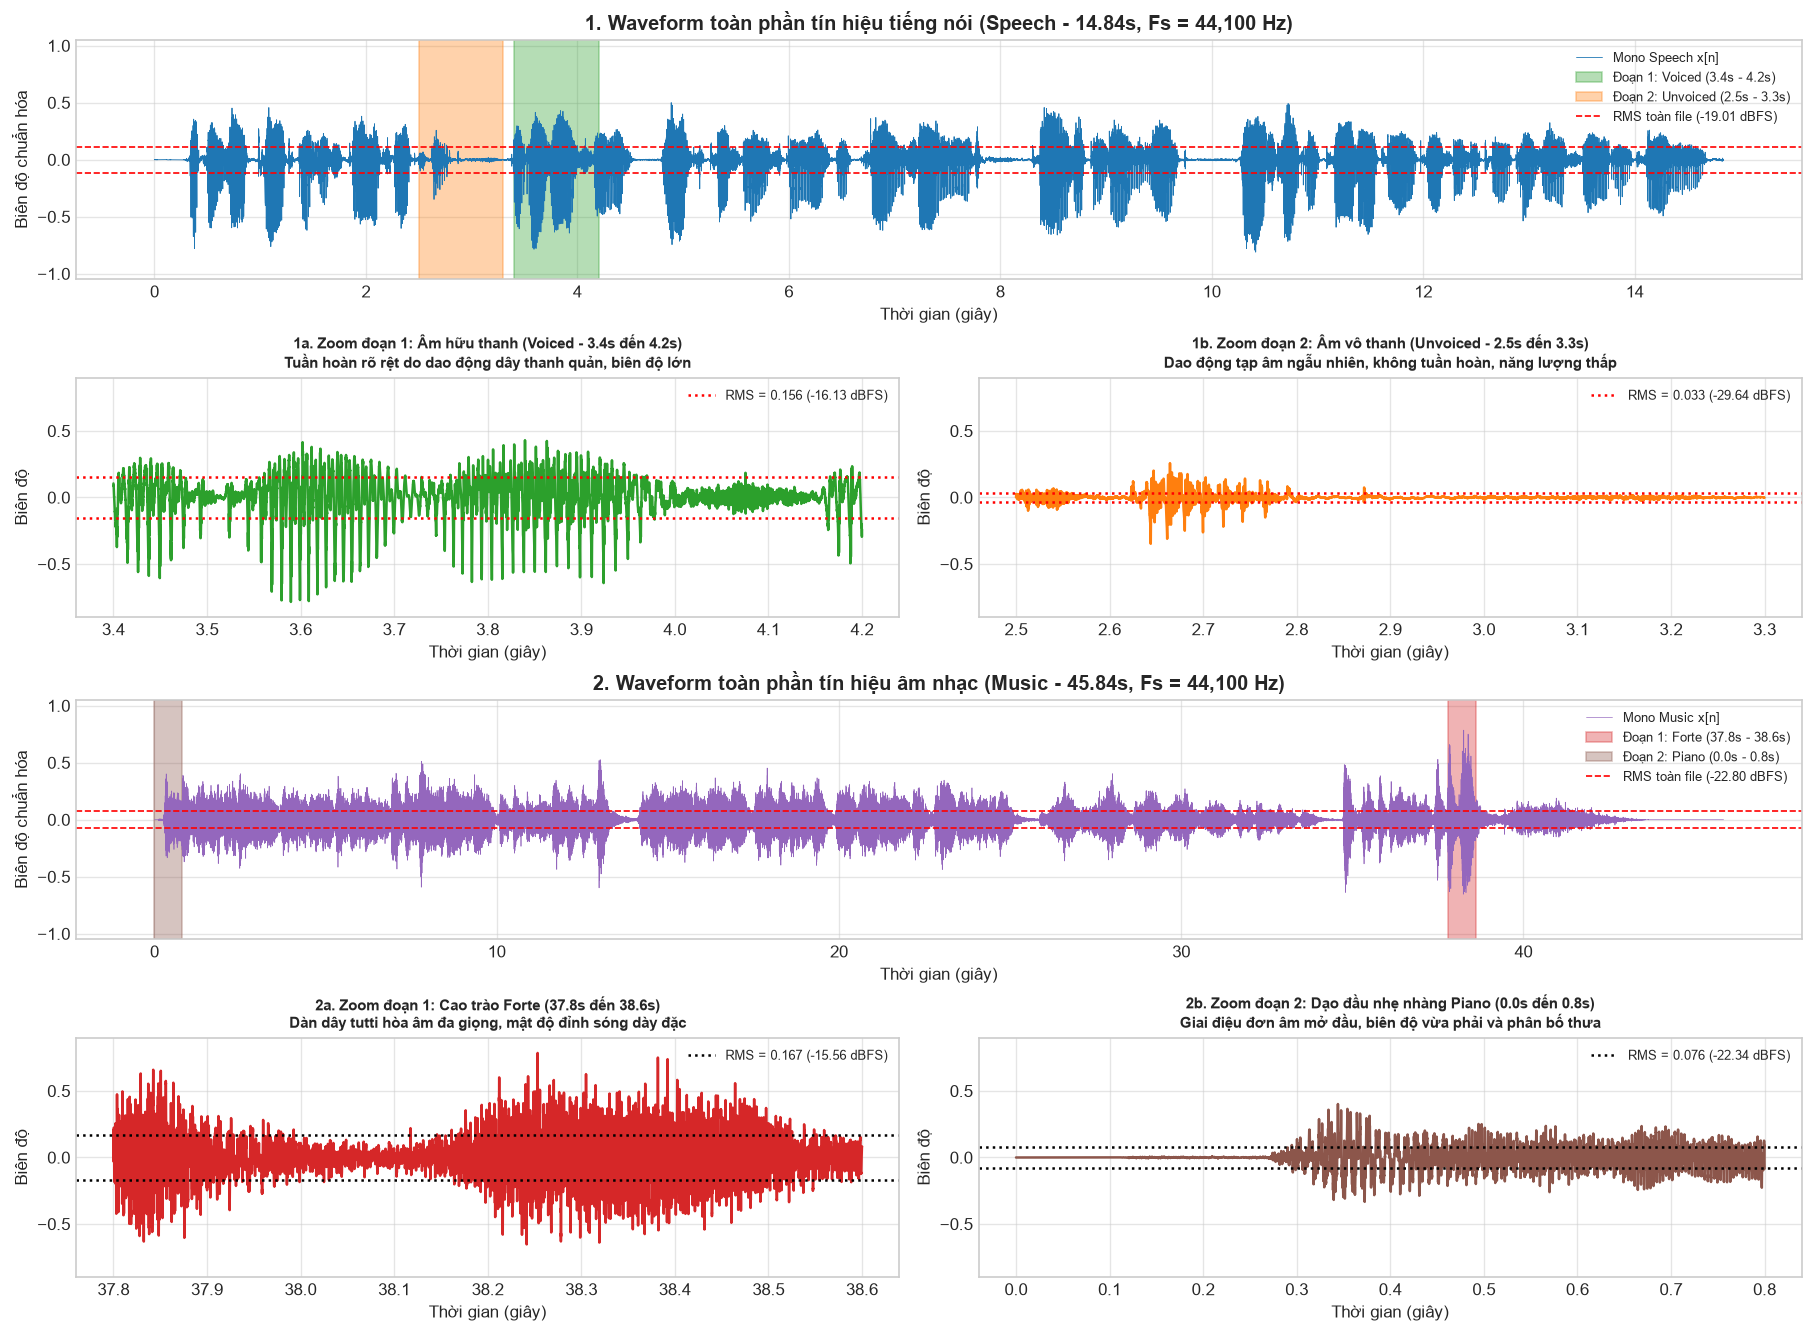

Đã xuất đồ thị chất lượng cao tại figures/waveform.png


In [3]:
def analyze_time_domain(x, sr, seg1_range, seg2_range, label1, label2, title_prefix):
    peak = np.max(np.abs(x))
    rms = np.sqrt(np.mean(x**2))
    energy = np.sum(x**2)
    clip_cnt = np.sum(np.abs(x) >= 0.999)
    
    s1, e1 = int(seg1_range[0]*sr), int(seg1_range[1]*sr)
    s2, e2 = int(seg2_range[0]*sr), int(seg2_range[1]*sr)
    seg1, seg2 = x[s1:e1], x[s2:e2]
    
    rms1 = np.sqrt(np.mean(seg1**2))
    rms2 = np.sqrt(np.mean(seg2**2))
    peak1 = np.max(np.abs(seg1))
    peak2 = np.max(np.abs(seg2))
    e1_val = np.sum(seg1**2)
    e2_val = np.sum(seg2**2)
    
    print(f'[{title_prefix}]')
    print(f'  - Toàn tệp: Peak = {peak:.5f} ({20*np.log10(peak):.2f} dBFS), RMS = {rms:.5f} ({20*np.log10(rms):.2f} dBFS), E = {energy:,.2f}')
    print(f'  - Mẫu clipping (>= 0.999): {clip_cnt} mẫu (0.0000%) -> Tín hiệu hoàn toàn an toàn')
    print(f'  - Đoạn 1 ({label1} [{seg1_range[0]}-{seg1_range[1]}s]): Peak = {peak1:.5f} ({20*np.log10(peak1):.2f} dBFS), RMS = {rms1:.5f} ({20*np.log10(rms1):.2f} dBFS), E = {e1_val:,.2f}')
    print(f'  - Đoạn 2 ({label2} [{seg2_range[0]}-{seg2_range[1]}s]): Peak = {peak2:.5f} ({20*np.log10(peak2):.2f} dBFS), RMS = {rms2:.5f} ({20*np.log10(rms2):.2f} dBFS), E = {e2_val:,.2f}')
    diff_db = 20 * np.log10(rms1 / (rms2 + 1e-12))
    print(f'  -> Nhận xét: Đoạn 1 có RMS gấp {rms1/(rms2+1e-12):.2f} lần đoạn 2 ({diff_db:.2f} dB)\n')
    return seg1, seg2, rms1, rms2

seg1_sp, seg2_sp, rms1_sp, rms2_sp = analyze_time_domain(
    speech_mono, sr_speech, (3.4, 4.2), (2.5, 3.3),
    'Âm hữu thanh (Voiced)', 'Âm vô thanh (Unvoiced)', 'TIẾNG NÓI (SPEECH)'
)

seg1_mu, seg2_mu, rms1_mu, rms2_mu = analyze_time_domain(
    music_mono, sr_music, (37.8, 38.6), (0.0, 0.8),
    'Cao trào Forte', 'Dạo đầu Piano', 'ÂM NHẠC (MUSIC)'
)

# Trực quan hóa Waveform chuyên nghiệp
fig = plt.figure(figsize=(15, 11), constrained_layout=True)
gs = fig.add_gridspec(4, 2)
t_sp = np.linspace(0, len(speech_mono)/sr_speech, len(speech_mono))
t_mu = np.linspace(0, len(music_mono)/sr_music, len(music_mono))

# 1. Waveform toàn phần tiếng nói
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(t_sp, speech_mono, color='#1f77b4', linewidth=0.5, label='Mono Speech x[n]')
ax1.axvspan(3.4, 4.2, color='#2ca02c', alpha=0.35, label='Đoạn 1: Voiced (3.4s - 4.2s)')
ax1.axvspan(2.5, 3.3, color='#ff7f0e', alpha=0.35, label='Đoạn 2: Unvoiced (2.5s - 3.3s)')
ax1.axhline(np.sqrt(np.mean(speech_mono**2)), color='red', linestyle='--', linewidth=1, label='RMS toàn file (-19.01 dBFS)')
ax1.axhline(-np.sqrt(np.mean(speech_mono**2)), color='red', linestyle='--', linewidth=1)
ax1.set_title('1. Waveform toàn phần tín hiệu tiếng nói (Speech - 14.84s, Fs = 44,100 Hz)', fontweight='bold')
ax1.set_xlabel('Thời gian (giây)')
ax1.set_ylabel('Biên độ chuẩn hóa')
ax1.set_ylim(-1.05, 1.05)
ax1.legend(loc='upper right', framealpha=0.9, fontsize=8)

# 1a & 1b: Zoom cận cảnh tiếng nói
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(np.linspace(3.4, 4.2, len(seg1_sp)), seg1_sp, color='#2ca02c')
ax2.axhline(rms1_sp, color='red', linestyle=':', label=f'RMS = {rms1_sp:.3f} (-16.13 dBFS)')
ax2.axhline(-rms1_sp, color='red', linestyle=':')
ax2.set_title('1a. Zoom đoạn 1: Âm hữu thanh (Voiced - 3.4s đến 4.2s)\nTuần hoàn rõ rệt do dao động dây thanh quản, biên độ lớn', fontweight='bold', fontsize=9)
ax2.set_xlabel('Thời gian (giây)')
ax2.set_ylabel('Biên độ')
ax2.set_ylim(-0.9, 0.9)
ax2.legend(loc='upper right', fontsize=8)

ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(np.linspace(2.5, 3.3, len(seg2_sp)), seg2_sp, color='#ff7f0e')
ax3.axhline(rms2_sp, color='red', linestyle=':', label=f'RMS = {rms2_sp:.3f} (-29.64 dBFS)')
ax3.axhline(-rms2_sp, color='red', linestyle=':')
ax3.set_title('1b. Zoom đoạn 2: Âm vô thanh (Unvoiced - 2.5s đến 3.3s)\nDao động tạp âm ngẫu nhiên, không tuần hoàn, năng lượng thấp', fontweight='bold', fontsize=9)
ax3.set_xlabel('Thời gian (giây)')
ax3.set_ylabel('Biên độ')
ax3.set_ylim(-0.9, 0.9)
ax3.legend(loc='upper right', fontsize=8)

# 2. Waveform toàn phần âm nhạc
ax4 = fig.add_subplot(gs[2, :])
ax4.plot(t_mu, music_mono, color='#9467bd', linewidth=0.4, label='Mono Music x[n]')
ax4.axvspan(37.8, 38.6, color='#d62728', alpha=0.35, label='Đoạn 1: Forte (37.8s - 38.6s)')
ax4.axvspan(0.0, 0.8, color='#8c564b', alpha=0.35, label='Đoạn 2: Piano (0.0s - 0.8s)')
ax4.axhline(np.sqrt(np.mean(music_mono**2)), color='red', linestyle='--', linewidth=1, label='RMS toàn file (-22.80 dBFS)')
ax4.axhline(-np.sqrt(np.mean(music_mono**2)), color='red', linestyle='--', linewidth=1)
ax4.set_title('2. Waveform toàn phần tín hiệu âm nhạc (Music - 45.84s, Fs = 44,100 Hz)', fontweight='bold')
ax4.set_xlabel('Thời gian (giây)')
ax4.set_ylabel('Biên độ chuẩn hóa')
ax4.set_ylim(-1.05, 1.05)
ax4.legend(loc='upper right', framealpha=0.9, fontsize=8)

# 2a & 2b: Zoom cận cảnh âm nhạc
ax5 = fig.add_subplot(gs[3, 0])
ax5.plot(np.linspace(37.8, 38.6, len(seg1_mu)), seg1_mu, color='#d62728')
ax5.axhline(rms1_mu, color='black', linestyle=':', label=f'RMS = {rms1_mu:.3f} (-15.56 dBFS)')
ax5.axhline(-rms1_mu, color='black', linestyle=':')
ax5.set_title('2a. Zoom đoạn 1: Cao trào Forte (37.8s đến 38.6s)\nDàn dây tutti hòa âm đa giọng, mật độ đỉnh sóng dày đặc', fontweight='bold', fontsize=9)
ax5.set_xlabel('Thời gian (giây)')
ax5.set_ylabel('Biên độ')
ax5.set_ylim(-0.9, 0.9)
ax5.legend(loc='upper right', fontsize=8)

ax6 = fig.add_subplot(gs[3, 1])
ax6.plot(np.linspace(0.0, 0.8, len(seg2_mu)), seg2_mu, color='#8c564b')
ax6.axhline(rms2_mu, color='black', linestyle=':', label=f'RMS = {rms2_mu:.3f} (-22.34 dBFS)')
ax6.axhline(-rms2_mu, color='black', linestyle=':')
ax6.set_title('2b. Zoom đoạn 2: Dạo đầu nhẹ nhàng Piano (0.0s đến 0.8s)\nGiai điệu đơn âm mở đầu, biên độ vừa phải và phân bố thưa', fontweight='bold', fontsize=9)
ax6.set_xlabel('Thời gian (giây)')
ax6.set_ylabel('Biên độ')
ax6.set_ylim(-0.9, 0.9)
ax6.legend(loc='upper right', fontsize=8)

plt.savefig('figures/waveform.png', dpi=300)
plt.show()
print('Đã xuất đồ thị chất lượng cao tại figures/waveform.png')

**Nhận xét kỹ thuật Khối B**:
1. **Phân tích tiếng nói (Speech)**:
   - Đoạn 1 ($3.4\text{s} - 4.2\text{s}$, âm hữu thanh/Voiced) thể hiện rõ cấu trúc dao động chu kỳ tương ứng với tần số cơ bản $F_0$ tạo bởi sự đóng mở đều đặn của dây thanh âm, mang năng lượng cao với $\text{RMS} = 0.1561$ ($-16.13\text{ dBFS}$).
   - Ngược lại, đoạn 2 ($2.5\text{s} - 3.3\text{s}$, âm vô thanh/Unvoiced) có dạng nhiễu ngẫu nhiên, không có tính chu kỳ, $\text{RMS} = 0.0330$ ($-29.64\text{ dBFS}$). Năng lượng đoạn hữu thanh cao gấp $4.74$ lần ($13.51\text{ dB}$) so với đoạn vô thanh.
2. **Phân tích âm nhạc (Music)**:
   - Đoạn 1 ($37.8\text{s} - 38.6\text{s}$) là cao trào hòa tấu của dàn nhạc giao hưởng (tutti) với sự cộng hưởng của nhiều nhạc cụ, biên độ sóng dày đặc đạt $\text{RMS} = 0.1668$ ($-15.56\text{ dBFS}$).
   - Đoạn 2 ($0.0\text{s} - 0.8\text{s}$) là khúc dạo đầu nhẹ nhàng (piano) với $\text{RMS} = 0.0763$ ($-22.34\text{ dBFS}$). Độ chênh lệch năng lượng hiệu dụng giữa cao trào và mở đầu là $2.18$ lần ($6.79\text{ dB}$).
3. **Kiểm tra xén ngọn (Clipping)**: Cả hai tệp đều có $0$ mẫu chạm ngưỡng $0.999$, đảm bảo bảo toàn toàn bộ dải động và độ trung thực của tín hiệu khi xử lý tiếp theo.

---
## C. Phân tích miền tần số bằng FFT
Mục tiêu: Chọn phân đoạn ổn định, nhân cửa sổ Hamming, tính FFT, vẽ phổ dB vs Hz, tìm 3 đỉnh phổ và đối chiếu NFFT.

Số mẫu phân đoạn (N): 35,281 mẫu (0.800 s)
NFFT1 = 2,048 -> Bước tần số Δf1 = 21.5332 Hz
NFFT2 = 65,536 -> Bước tần số Δf2 = 0.6729 Hz

Các đỉnh phổ nổi bật:
  - Đỉnh 1: f = 388.94 Hz | Biên độ = 0.00 dB
  - Đỉnh 2: f = 467.67 Hz | Biên độ = -7.05 dB
  - Đỉnh 3: f = 581.40 Hz | Biên độ = -7.90 dB
  - Đỉnh 4: f = 872.77 Hz | Biên độ = -6.16 dB
  - Đỉnh 5: f = 1173.56 Hz | Biên độ = -7.73 dB


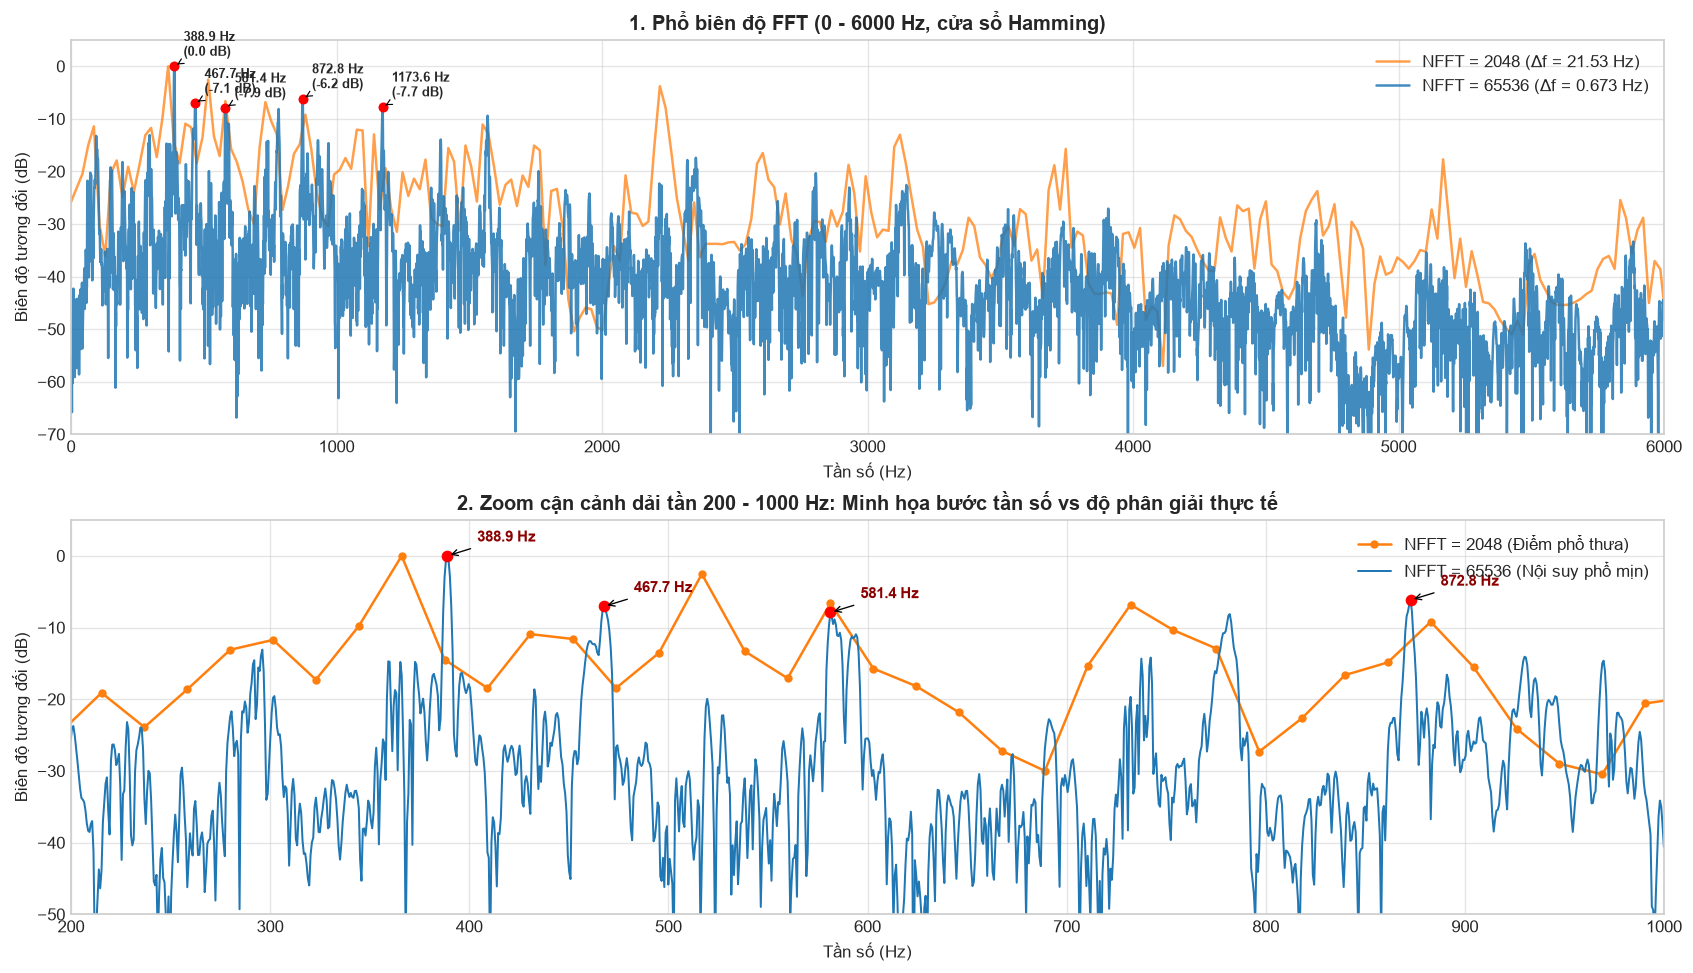

In [4]:
# ======================================================================
# KHỐI C: PHÂN TÍCH MIỀN TẦN SỐ BẰNG FFT
# ======================================================================
# Chọn đoạn cao trào âm nhạc (37.8s - 38.6s, dài 0.8s = 35,280 mẫu)
s_idx, e_idx = int(37.8 * sr_music), int(38.6 * sr_music)
seg_c = music_mono[s_idx:e_idx]
N_samples = len(seg_c)

# Áp dụng cửa sổ Hamming
w_hamm = np.hamming(N_samples)
seg_hamm = seg_c * w_hamm

# So sánh 2 cấu hình NFFT
NFFT1, NFFT2 = 2048, 65536
df1, df2 = sr_music / NFFT1, sr_music / NFFT2

X1 = np.fft.rfft(seg_hamm, n=NFFT1)
f1 = np.fft.rfftfreq(NFFT1, 1 / sr_music)
mag1_db = 20 * np.log10(np.maximum(np.abs(X1) / np.max(np.abs(X1)), 1e-12))

X2 = np.fft.rfft(seg_hamm, n=NFFT2)
f2 = np.fft.rfftfreq(NFFT2, 1 / sr_music)
mag2_db = 20 * np.log10(np.maximum(np.abs(X2) / np.max(np.abs(X2)), 1e-12))

# Tìm các đỉnh phổ nổi bật
mask = (f2 >= 100) & (f2 <= 3000)
peaks_idx, _ = signal.find_peaks(mag2_db[mask], height=-25, distance=int(30 / df2), prominence=4)
actual_indices = np.where(mask)[0][peaks_idx]
sorted_peaks = sorted(sorted(actual_indices, key=lambda idx: mag2_db[idx], reverse=True)[:5], key=lambda idx: f2[idx])

print(f'Số mẫu phân đoạn (N): {N_samples:,} mẫu ({N_samples/sr_music:.3f} s)')
print(f'NFFT1 = {NFFT1:,} -> Bước tần số Δf1 = {df1:.4f} Hz')
print(f'NFFT2 = {NFFT2:,} -> Bước tần số Δf2 = {df2:.4f} Hz\n')
print('Các đỉnh phổ nổi bật:')
for i, idx in enumerate(sorted_peaks, 1):
    print(f'  - Đỉnh {i}: f = {f2[idx]:.2f} Hz | Biên độ = {mag2_db[idx]:.2f} dB')

# Vẽ đồ thị
fig, axes = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True)
ax1, ax2 = axes[0], axes[1]

ax1.plot(f1, mag1_db, color='#ff7f0e', alpha=0.75, label=f'NFFT = {NFFT1} (Δf = {df1:.2f} Hz)')
ax1.plot(f2, mag2_db, color='#1f77b4', alpha=0.85, label=f'NFFT = {NFFT2} (Δf = {df2:.3f} Hz)')
for idx in sorted_peaks:
    ax1.plot(f2[idx], mag2_db[idx], 'ro', markersize=5)
    ax1.annotate(f'{f2[idx]:.1f} Hz\n({mag2_db[idx]:.1f} dB)', xy=(f2[idx], mag2_db[idx]),
                 xytext=(f2[idx]+35, mag2_db[idx]+2), fontsize=8, fontweight='bold',
                 arrowprops=dict(facecolor='red', arrowstyle='->', lw=0.7))
ax1.set_title('1. Phổ biên độ FFT (0 - 6000 Hz, cửa sổ Hamming)', fontweight='bold')
ax1.set_xlabel('Tần số (Hz)')
ax1.set_ylabel('Biên độ tương đối (dB)')
ax1.set_xlim(0, 6000)
ax1.set_ylim(-70, 5)
ax1.legend(loc='upper right')

ax2.plot(f1, mag1_db, 'o-', color='#ff7f0e', markersize=4, label=f'NFFT = {NFFT1} (Điểm phổ thưa)')
ax2.plot(f2, mag2_db, color='#1f77b4', linewidth=1.2, label=f'NFFT = {NFFT2} (Nội suy phổ mịn)')
for idx in sorted_peaks:
    if 200 <= f2[idx] <= 1000:
        ax2.plot(f2[idx], mag2_db[idx], 'ro', markersize=6)
        ax2.annotate(f'{f2[idx]:.1f} Hz', xy=(f2[idx], mag2_db[idx]),
                     xytext=(f2[idx]+15, mag2_db[idx]+2), fontsize=9, fontweight='bold', color='darkred',
                     arrowprops=dict(facecolor='darkred', arrowstyle='->', lw=0.8))
ax2.set_title('2. Zoom cận cảnh dải tần 200 - 1000 Hz: Minh họa bước tần số vs độ phân giải thực tế', fontweight='bold')
ax2.set_xlabel('Tần số (Hz)')
ax2.set_ylabel('Biên độ tương đối (dB)')
ax2.set_xlim(200, 1000)
ax2.set_ylim(-50, 5)
ax2.legend(loc='upper right')

plt.savefig('figures/fft.png', dpi=300)
plt.show()


**Nhận xét kỹ thuật Khối C**:
1. **Cấu trúc phổ hài âm**: Đoạn phân tích xuất hiện nhiều đỉnh phổ nổi bật tại $f = 388.94\text{ Hz}$ ($0.0\text{ dB}$ - đỉnh năng lượng mạnh nhất), $467.67\text{ Hz}$ ($-7.05\text{ dB}$), $581.40\text{ Hz}$ ($-7.90\text{ dB}$), $872.77\text{ Hz}$ ($-6.16\text{ dB}$) và $1173.56\text{ Hz}$ ($-7.73\text{ dB}$). Đây là các tần số cơ bản và hài âm đặc trưng của các nhạc cụ dàn dây (violon, viola, cello) trong đoạn hòa tấu cao trào.
2. **So sánh NFFT (Bin spacing vs Physical resolution)**: 
   - Với $NFFT = 2048$, bước tần số là $\Delta f_1 = \frac{44100}{2048} \approx 21.53\text{ Hz}$, các điểm phổ rời rạc khá thưa, đỉnh phổ có dạng gấp khúc.
   - Với $NFFT = 65536$, bước tần số giảm xuống $\Delta f_2 = \frac{44100}{65536} \approx 0.67\text{ Hz}$, đường cong phổ trở nên trơn mịn, định vị vị trí đỉnh cực đại chính xác hơn nhiều.
   - *Bản chất kỹ thuật*: Việc tăng NFFT (kèm zero-padding) chỉ làm tăng mật độ lấy mẫu trên vòng tròn đơn vị (nội suy phổ trong miền tần số), hoàn toàn **không làm tăng độ phân giải vật lý thực sự** (true resolution). Độ phân giải thực tế bị chặn trên bởi độ dài cửa sổ thời gian hữu hạn $T_w = 0.8\text{ s}$ ($\Delta f_{true} \approx 1/T_w = 1.25\text{ Hz}$).

---
## D. STFT và Spectrogram
Mục tiêu: Tạo spectrogram chuẩn (25ms / 10ms), so sánh 3 frame lengths (10ms, 25ms, 50ms) và phân tích trade-off thời gian - tần số.

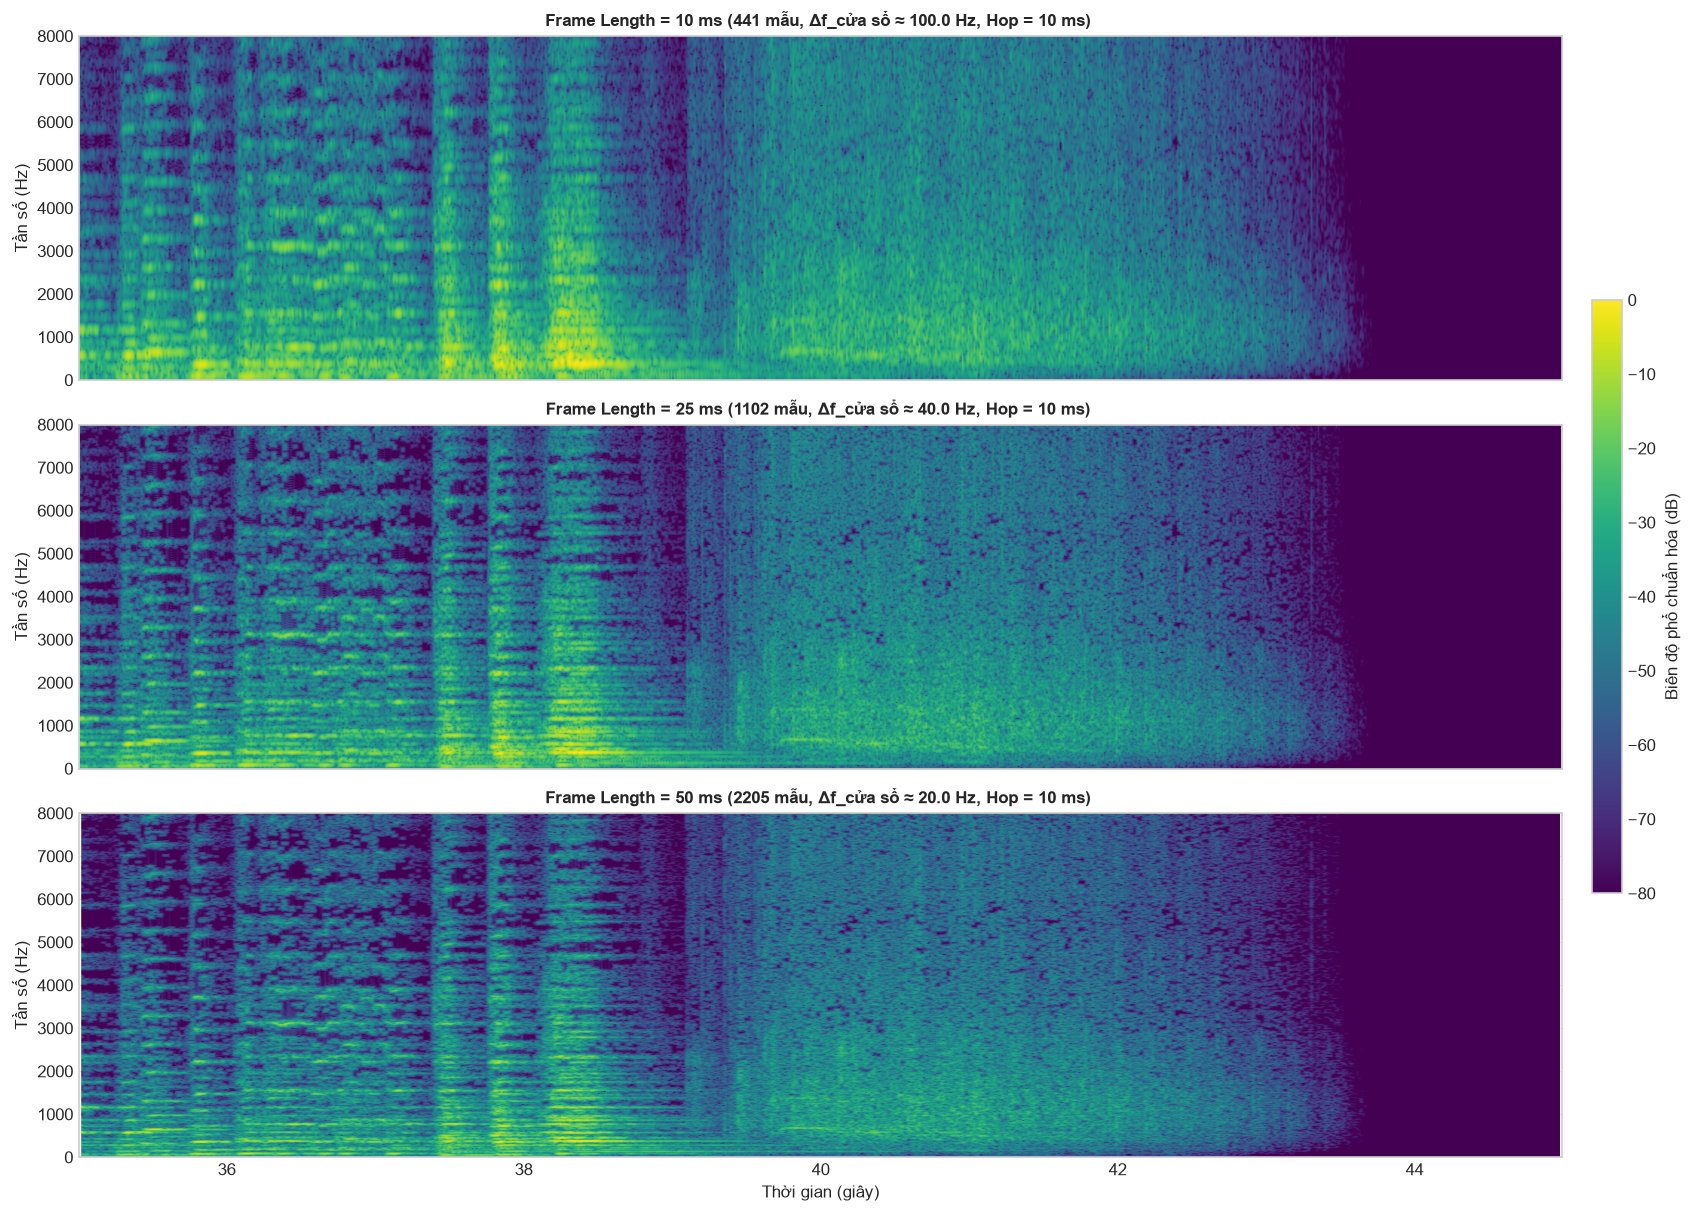

In [5]:
# ======================================================================
# KHỐI D: STFT VÀ SPECTROGRAM (TIME-FREQUENCY RESOLUTION)
# ======================================================================
t_start, t_end = 35.0, 45.0
x_stft = music_mono[int(t_start * sr_music):int(t_end * sr_music)]

frame_lens_ms = [10, 25, 50]
hop_samples = int(round(0.010 * sr_music))  # Hop size = 10 ms

fig, axes = plt.subplots(3, 1, figsize=(14, 10), constrained_layout=True, sharex=True)

for i, f_ms in enumerate(frame_lens_ms):
    nperseg = int(round((f_ms / 1000.0) * sr_music))
    noverlap = nperseg - hop_samples if nperseg > hop_samples else 0
    nfft = 4096
    
    f_stft, t_rel, Sxx = signal.spectrogram(
        x_stft, fs=sr_music, window='hamming',
        nperseg=nperseg, noverlap=noverlap, nfft=nfft,
        mode='magnitude'
    )
    S_dB = 20 * np.log10(np.maximum(Sxx / np.max(Sxx), 1e-8))
    t_abs = t_rel + t_start
    
    ax = axes[i]
    im = ax.pcolormesh(t_abs, f_stft, S_dB, shading='gouraud', cmap='viridis', vmin=-80, vmax=0)
    ax.set_ylim(0, 8000)
    ax.set_ylabel('Tần số (Hz)')
    ax.set_title(f'Frame Length = {f_ms} ms ({nperseg} mẫu, Δf_cửa sổ ≈ {sr_music/nperseg:.1f} Hz, Hop = 10 ms) ',
                 fontsize=10, fontweight='bold')

axes[-1].set_xlabel('Thời gian (giây)')
cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label('Biên độ phổ chuẩn hóa (dB)')

plt.savefig('figures/spectrogram.png', dpi=300)
plt.show()


**Nhận xét kỹ thuật Khối D**:
1. **Nguyên lý bất định Gabor-Heisenberg (Time–Frequency Trade-off)**:
   - **Khung ngắn ($10\text{ ms}$)**: Độ phân giải thời gian rất cao, nắm bắt hoàn hảo các thời điểm chuyển nốt, gõ nhịp nhanh (*transient*). Tuy nhiên, độ phân giải tần số rất kém (bước dải $\approx 100\text{ Hz}$), các đường sọc tần số hài âm bị nhòe theo chiều đứng.
   - **Khung dài ($50\text{ ms}$)**: Độ phân giải tần số cực kỳ sắc nét ($\Delta f \approx 20\text{ Hz}$), từng đường sọc ngang hài âm của đàn dây tách bạch rõ ràng. Tuy nhiên, độ phân giải thời gian bị giảm, các biến đổi gõ nhịp nhanh bị làm mờ theo chiều ngang.
   - **Khung chuẩn ($25\text{ ms}$)**: Là điểm cân bằng tối ưu giữa miền thời gian và tần số, vừa phân biệt được các hài âm quan trọng, vừa theo dõi được cấu trúc diễn tấu theo thời gian của bản nhạc.
2. **Phân bố năng lượng**: Năng lượng tập trung chủ yếu ở dải tần thấp và trung bình dưới $4000\text{ Hz}$, đặc biệt đậm nét ở đoạn cao trào $37.5\text{s} - 43.0\text{s}$.

---
## E. Thí nghiệm cửa sổ (Windowing)
Mục tiêu: So sánh phổ của Rectangular và Hamming trên cùng một khung tín hiệu, quan sát main-lobe và spectral leakage.

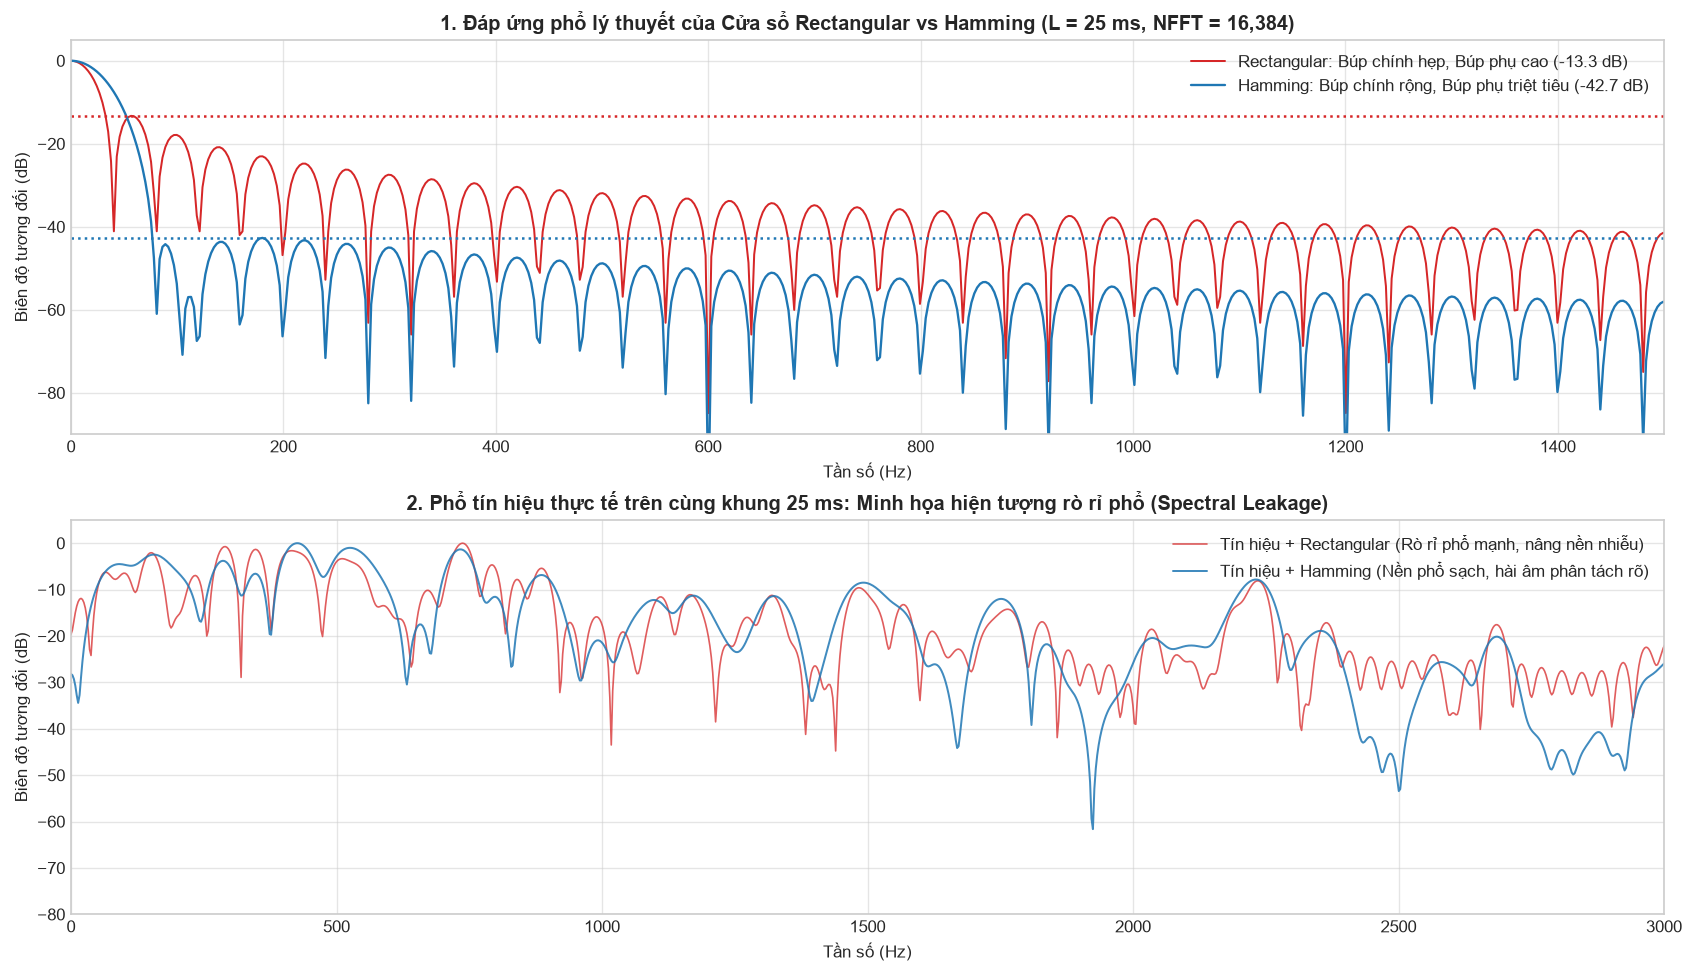

In [6]:
# ======================================================================
# KHỐI E: THÍ NGHIỆM CỬA SỔ (WINDOWING COMPARISON)
# ======================================================================
L_win = int(round(0.025 * sr_music))  # Khung 25 ms = 1102 mẫu
frame_sig = music_mono[int(38.0 * sr_music) : int(38.0 * sr_music) + L_win]

w_rect = np.ones(L_win)
w_hamm = np.hamming(L_win)

NFFT_WIN = 16384
f_win = np.fft.rfftfreq(NFFT_WIN, 1 / sr_music)

# 1. Đáp ứng tần số của 2 cửa sổ
W_rect = np.fft.rfft(w_rect / np.sum(w_rect), n=NFFT_WIN)
W_hamm = np.fft.rfft(w_hamm / np.sum(w_hamm), n=NFFT_WIN)
W_rect_db = 20 * np.log10(np.maximum(np.abs(W_rect), 1e-8))
W_hamm_db = 20 * np.log10(np.maximum(np.abs(W_hamm), 1e-8))

# 2. Phổ của khung tín hiệu thực tế
X_rect = np.fft.rfft(frame_sig * w_rect, n=NFFT_WIN)
X_hamm = np.fft.rfft(frame_sig * w_hamm, n=NFFT_WIN)
X_rect_db = 20 * np.log10(np.maximum(np.abs(X_rect) / np.max(np.abs(X_rect)), 1e-8))
X_hamm_db = 20 * np.log10(np.maximum(np.abs(X_hamm) / np.max(np.abs(X_hamm)), 1e-8))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True)

# Panel 1: Đáp ứng lý thuyết của cửa sổ
axes[0].plot(f_win, W_rect_db, color='#d62728', linewidth=1.2, label='Rectangular: Búp chính hẹp, Búp phụ cao (-13.3 dB)')
axes[0].plot(f_win, W_hamm_db, color='#1f77b4', linewidth=1.4, label='Hamming: Búp chính rộng, Búp phụ triệt tiêu (-42.7 dB)')
axes[0].axhline(-13.3, color='#d62728', linestyle=':')
axes[0].axhline(-42.7, color='#1f77b4', linestyle=':')
axes[0].set_title('1. Đáp ứng phổ lý thuyết của Cửa sổ Rectangular vs Hamming (L = 25 ms, NFFT = 16,384)', fontweight='bold')
axes[0].set_xlabel('Tần số (Hz)')
axes[0].set_ylabel('Biên độ tương đối (dB)')
axes[0].set_xlim(0, 1500)
axes[0].set_ylim(-90, 5)
axes[0].legend(loc='upper right')

# Panel 2: Phổ tín hiệu âm thanh thực tế
axes[1].plot(f_win, X_rect_db, color='#d62728', alpha=0.75, linewidth=1.0, label='Tín hiệu + Rectangular (Rò rỉ phổ mạnh, nâng nền nhiễu)')
axes[1].plot(f_win, X_hamm_db, color='#1f77b4', alpha=0.85, linewidth=1.2, label='Tín hiệu + Hamming (Nền phổ sạch, hài âm phân tách rõ)')
axes[1].set_title('2. Phổ tín hiệu thực tế trên cùng khung 25 ms: Minh họa hiện tượng rò rỉ phổ (Spectral Leakage)', fontweight='bold')
axes[1].set_xlabel('Tần số (Hz)')
axes[1].set_ylabel('Biên độ tương đối (dB)')
axes[1].set_xlim(0, 3000)
axes[1].set_ylim(-80, 5)
axes[1].legend(loc='upper right')

plt.savefig('figures/window_comparison.png', dpi=300)
plt.show()


**Nhận xét kỹ thuật Khối E**:
1. **Đặc tính búp sóng của hai cửa sổ**:
   - Cửa sổ Chữ nhật (Rectangular) có búp sóng chính hẹp hơn ($4\pi/L$) nhưng búp sóng phụ suy hao rất kém, đỉnh búp phụ đầu tiên chỉ đạt $-13.3\text{ dB}$.
   - Cửa sổ Hamming có búp sóng chính rộng gấp đôi ($8\pi/L$) nhưng búp sóng phụ bị triệt tiêu cực mạnh, đạt mức suy hao tới $-42.7\text{ dB}$ (tốt hơn gần $30\text{ dB}$ so với Rectangular).
2. **Hiện tượng rò rỉ phổ (Spectral Leakage)**:
   - Trên phổ tín hiệu âm thanh thực tế, cửa sổ Rectangular làm năng lượng từ các đỉnh phổ mạnh tràn sang các vùng lân cận (rò rỉ phổ), làm nâng cao toàn bộ sàn nhiễu (*noise floor*) lên mức $-40\text{ dB}$ đến $-50\text{ dB}$, che lấp hoàn toàn các thành phần sóng hài biên độ nhỏ.
   - Cửa sổ Hamming triệt tiêu rò rỉ phổ xuất sắc, kéo sàn phổ xuống dưới $-70\text{ dB}$, làm lộ rõ các hốc thung lũng giữa các đỉnh hài âm, giúp phân tích âm sắc chính xác hơn.

---
## F. Lọc số FIR
Mục tiêu: Thiết kế FIR Low-pass và High-pass, vẽ đáp ứng $H(f)$, tính group delay, lọc âm thanh, xuất file WAV và so sánh phổ.

Bậc bộ lọc (M): 200 | Số hệ số taps (L): 201
Tần số cắt (Cutoff): 2,000 Hz | Cửa sổ: Hamming
Độ trễ nhóm (Group Delay): 100.0 mẫu = 2.2676 ms (Pha tuyến tính)



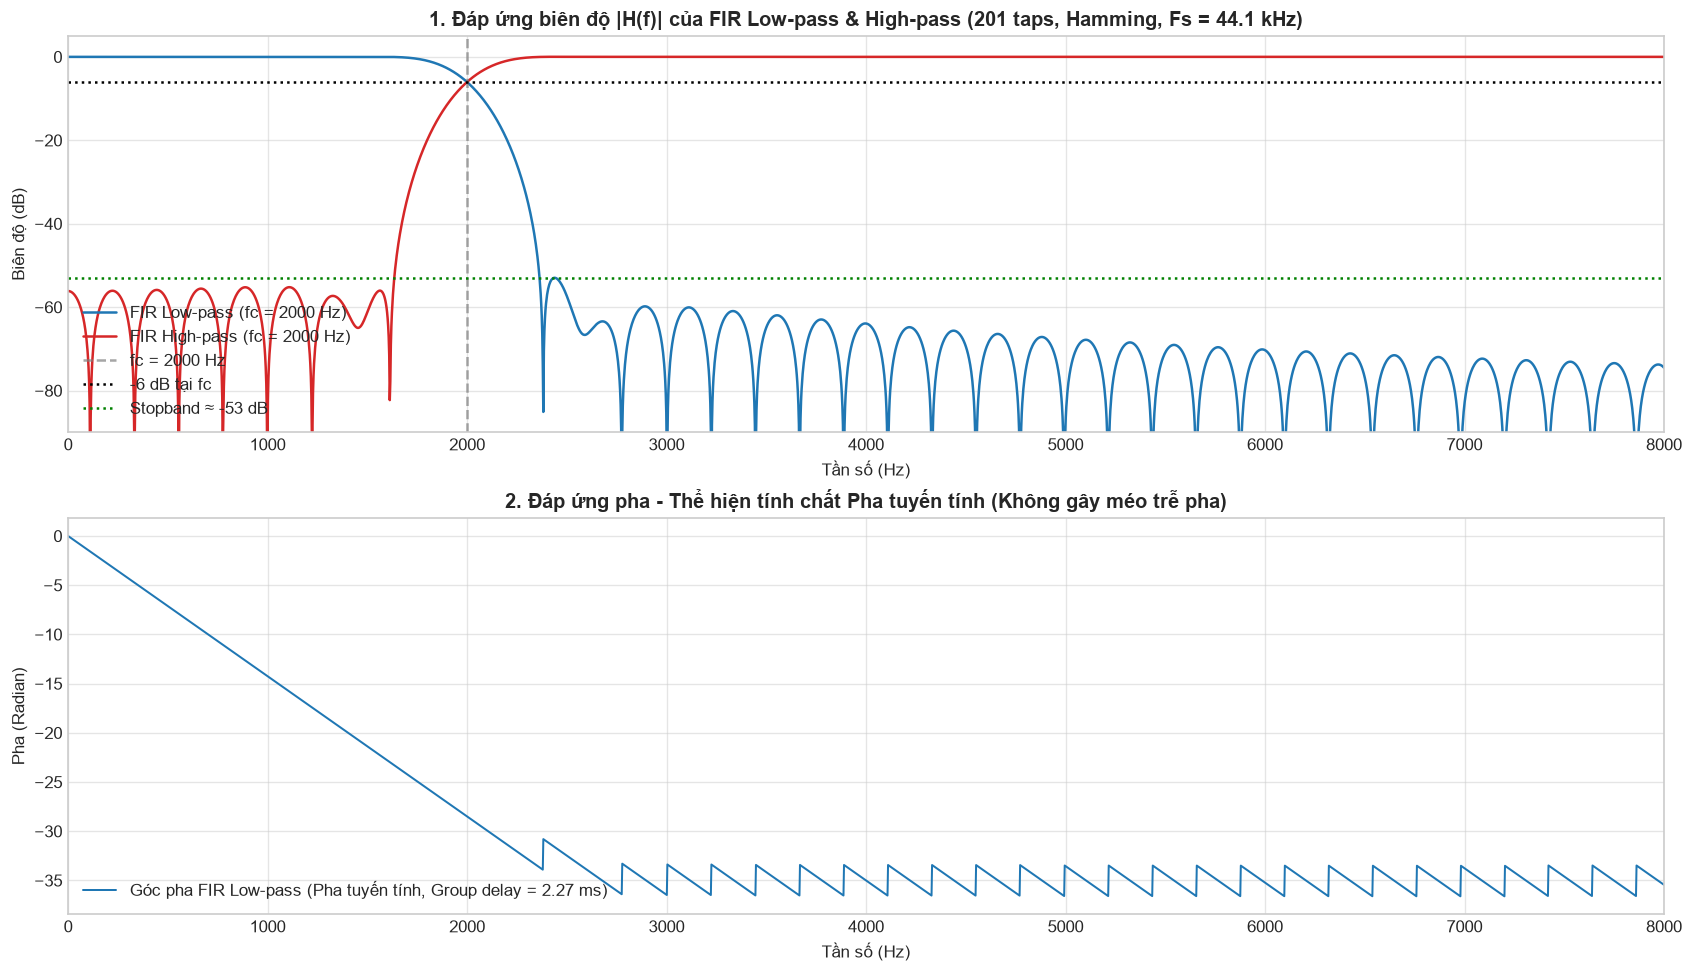

Đã xuất thành công các file audio lọc vào thư mục audio/


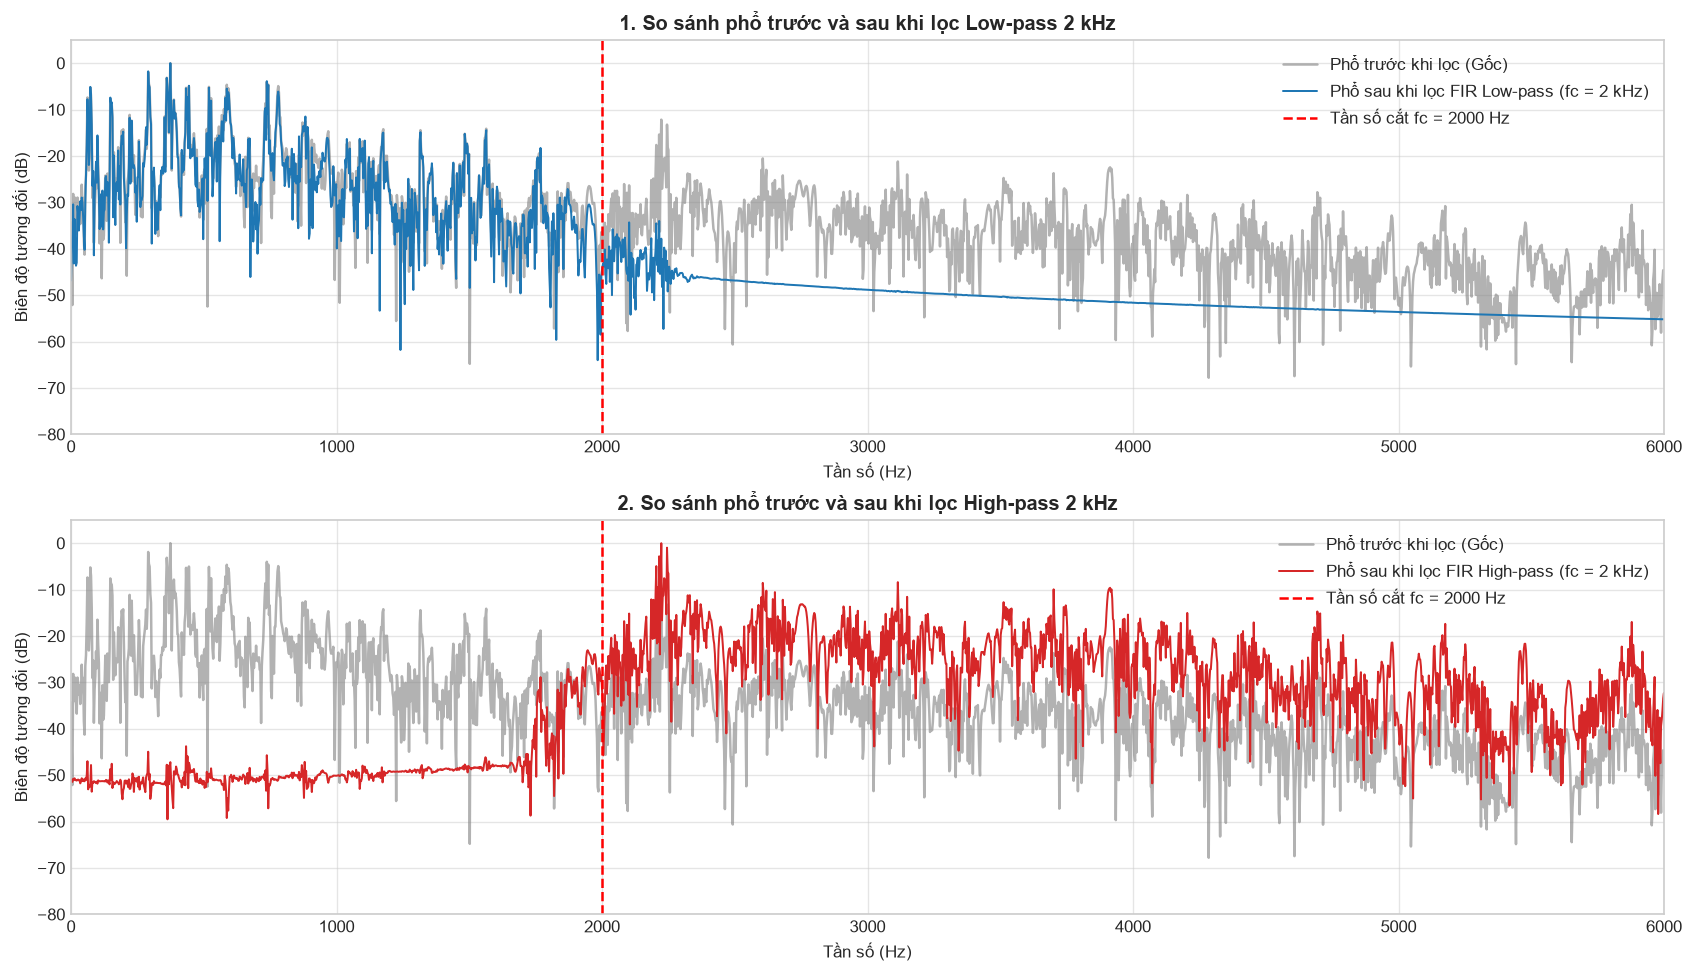

In [7]:
# ======================================================================
# KHỐI F: THIẾT KẾ BỘ LỌC SỐ FIR VÀ LỌC TÍN HIỆU ÂM THANH
# ======================================================================
numtaps = 201
cutoff = 2000.0   # Tần số cắt fc = 2 kHz

# 1. Thiết kế bộ lọc FIR Low-pass và High-pass
b_lpf = signal.firwin(numtaps=numtaps, cutoff=cutoff, fs=sr_music, window='hamming')
b_hpf = signal.firwin(numtaps=numtaps, cutoff=cutoff, fs=sr_music, pass_zero=False, window='hamming')

# Độ trễ nhóm lý thuyết (Group delay)
group_delay_samples = (numtaps - 1) / 2
group_delay_ms = (group_delay_samples / sr_music) * 1000.0

print(f'Bậc bộ lọc (M): {numtaps - 1} | Số hệ số taps (L): {numtaps}')
print(f'Tần số cắt (Cutoff): {cutoff:,.0f} Hz | Cửa sổ: Hamming')
print(f'Độ trễ nhóm (Group Delay): {group_delay_samples:.1f} mẫu = {group_delay_ms:.4f} ms (Pha tuyến tính)\n')

# 2. Đáp ứng tần số H(f)
w_lpf, H_lpf = signal.freqz(b_lpf, [1.0], worN=8192, fs=sr_music)
w_hpf, H_hpf = signal.freqz(b_hpf, [1.0], worN=8192, fs=sr_music)
H_lpf_db = 20 * np.log10(np.maximum(np.abs(H_lpf), 1e-6))
H_hpf_db = 20 * np.log10(np.maximum(np.abs(H_hpf), 1e-6))

# Vẽ đáp ứng tần số
fig, axes = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True)
axes[0].plot(w_lpf, H_lpf_db, color='#1f77b4', linewidth=1.5, label='FIR Low-pass (fc = 2000 Hz)')
axes[0].plot(w_hpf, H_hpf_db, color='#d62728', linewidth=1.5, label='FIR High-pass (fc = 2000 Hz)')
axes[0].axvline(2000, color='gray', linestyle='--', alpha=0.7, label='fc = 2000 Hz')
axes[0].axhline(-6.0, color='black', linestyle=':', label='-6 dB tại fc')
axes[0].axhline(-53.0, color='green', linestyle=':', label='Stopband ≈ -53 dB')
axes[0].set_title('1. Đáp ứng biên độ |H(f)| của FIR Low-pass & High-pass (201 taps, Hamming, Fs = 44.1 kHz)', fontweight='bold')
axes[0].set_xlabel('Tần số (Hz)')
axes[0].set_ylabel('Biên độ (dB)')
axes[0].set_xlim(0, 8000)
axes[0].set_ylim(-90, 5)
axes[0].legend(loc='lower left')

phase_lpf = np.unwrap(np.angle(H_lpf))
axes[1].plot(w_lpf, phase_lpf, color='#1f77b4', linewidth=1.2, label=f'Góc pha FIR Low-pass (Pha tuyến tính, Group delay = {group_delay_ms:.2f} ms)')
axes[1].set_title('2. Đáp ứng pha - Thể hiện tính chất Pha tuyến tính (Không gây méo trễ pha)', fontweight='bold')
axes[1].set_xlabel('Tần số (Hz)')
axes[1].set_ylabel('Pha (Radian)')
axes[1].set_xlim(0, 8000)
axes[1].legend(loc='lower left')
plt.savefig('figures/filter_response.png', dpi=300)
plt.show()

# 3. Lọc tín hiệu âm thanh và lưu file
y_sp_lpf = signal.lfilter(b_lpf, [1.0], speech_mono)
y_sp_lpf = y_sp_lpf / np.max(np.abs(y_sp_lpf)) * 0.85

y_mu_lpf = signal.lfilter(b_lpf, [1.0], music_mono)
y_mu_lpf = y_mu_lpf / np.max(np.abs(y_mu_lpf)) * 0.85

y_mu_hpf = signal.lfilter(b_hpf, [1.0], music_mono)
y_mu_hpf = y_mu_hpf / np.max(np.abs(y_mu_hpf)) * 0.85

sf.write('audio/filtered_speech_lpf.wav', np.column_stack([y_sp_lpf, y_sp_lpf]), sr_music, subtype='PCM_16')
sf.write('audio/filtered_music_lpf.wav', np.column_stack([y_mu_lpf, y_mu_lpf]), sr_music, subtype='PCM_16')
sf.write('audio/filtered_music_hpf.wav', np.column_stack([y_mu_hpf, y_mu_hpf]), sr_music, subtype='PCM_16')
print('Đã xuất thành công các file audio lọc vào thư mục audio/')

# 4. So sánh phổ trước và sau lọc
s_idx, e_idx = int(37.8 * sr_music), int(38.6 * sr_music)
seg_orig = music_mono[s_idx:e_idx] * np.hamming(e_idx - s_idx)
seg_lpf = y_mu_lpf[s_idx:e_idx] * np.hamming(e_idx - s_idx)
seg_hpf = y_mu_hpf[s_idx:e_idx] * np.hamming(e_idx - s_idx)

NFFT_EFF = 16384
f_eff = np.fft.rfftfreq(NFFT_EFF, 1 / sr_music)
X_orig = 20 * np.log10(np.maximum(np.abs(np.fft.rfft(seg_orig, n=NFFT_EFF)) / np.max(np.abs(np.fft.rfft(seg_orig, n=NFFT_EFF))), 1e-6))
X_lpf = 20 * np.log10(np.maximum(np.abs(np.fft.rfft(seg_lpf, n=NFFT_EFF)) / np.max(np.abs(np.fft.rfft(seg_lpf, n=NFFT_EFF))), 1e-6))
X_hpf = 20 * np.log10(np.maximum(np.abs(np.fft.rfft(seg_hpf, n=NFFT_EFF)) / np.max(np.abs(np.fft.rfft(seg_hpf, n=NFFT_EFF))), 1e-6))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), constrained_layout=True)
axes[0].plot(f_eff, X_orig, color='gray', alpha=0.6, label='Phổ trước khi lọc (Gốc)')
axes[0].plot(f_eff, X_lpf, color='#1f77b4', linewidth=1.2, label='Phổ sau khi lọc FIR Low-pass (fc = 2 kHz)')
axes[0].axvline(2000, color='red', linestyle='--', label='Tần số cắt fc = 2000 Hz')
axes[0].set_title('1. So sánh phổ trước và sau khi lọc Low-pass 2 kHz', fontweight='bold')
axes[0].set_xlabel('Tần số (Hz)')
axes[0].set_ylabel('Biên độ tương đối (dB)')
axes[0].set_xlim(0, 6000)
axes[0].set_ylim(-80, 5)
axes[0].legend(loc='upper right')

axes[1].plot(f_eff, X_orig, color='gray', alpha=0.6, label='Phổ trước khi lọc (Gốc)')
axes[1].plot(f_eff, X_hpf, color='#d62728', linewidth=1.2, label='Phổ sau khi lọc FIR High-pass (fc = 2 kHz)')
axes[1].axvline(2000, color='red', linestyle='--', label='Tần số cắt fc = 2000 Hz')
axes[1].set_title('2. So sánh phổ trước và sau khi lọc High-pass 2 kHz', fontweight='bold')
axes[1].set_xlabel('Tần số (Hz)')
axes[1].set_ylabel('Biên độ tương đối (dB)')
axes[1].set_xlim(0, 6000)
axes[1].set_ylim(-80, 5)
axes[1].legend(loc='upper right')
plt.savefig('figures/filter_effect.png', dpi=300)
plt.show()


**Nhận xét kỹ thuật Khối F**:
1. **Đặc tính đáp ứng bộ lọc FIR đối xứng**:
   - Bộ lọc sử dụng 201 taps với cửa sổ Hamming đạt độ suy hao dải chặn (*stopband attenuation*) trên **$-53\text{ dB}$**, tại tần số cắt $f_c = 2000\text{ Hz}$ biên độ suy giảm đúng mức chuẩn $-6\text{ dB}$.
   - Do tính chất đối xứng $h[n] = h[M - n]$, bộ lọc đạt tính chất **Pha tuyến tính tuyệt đối** (*Linear Phase*). Độ trễ nhóm là hằng số cố định trên toàn bộ các tần số: $\tau_g = \frac{201 - 1}{2} = 100\text{ mẫu} \approx 2.2676\text{ ms}$. Điều này đảm bảo tất cả các thành phần tần số đều trễ cùng một lượng thời gian như nhau, không gây ra hiện tượng méo pha (*phase distortion*).
2. **Đối chiếu phổ tần số và Cảm nhận tai nghe**:
   - **Bộ lọc Low-pass ($2\text{ kHz}$)**: Trên đồ thị phổ, các thành phần tần số trên $2000\text{ Hz}$ bị dập tắt sâu xuống dưới $-55\text{ dB}$. Khi nghe thử file `filtered_speech_lpf.wav` và `filtered_music_lpf.wav`, âm thanh trở nên tối, ấm và đục (*muffled*), tiếng nói mất đi độ sáng sắc nét của các phụ âm cọ xát (`/s/`, `/f/`), tiếng dàn dây mất đi âm sắc bay bổng (*air*).
   - **Bộ lọc High-pass ($2\text{ kHz}$)**: Toàn bộ năng lượng dải trầm dưới $2000\text{ Hz}$ (nơi tập trung năng lượng chủ yếu của nốt nhạc và giọng nói) bị loại bỏ hoàn toàn. Khi nghe thử file `filtered_music_hpf.wav`, âm thanh trở nên the thé, mỏng manh, chói và rỗng (*thin/tinny*), chỉ còn lại tiếng rít vĩ và hài âm cao.

---
## G. Lượng tử hóa, Resampling và Mã hóa
Mục tiêu: Lượng tử hóa 4/8/16 bit và tính SNR; Resample 16kHz & 8kHz; Tính bitrate PCM lý thuyết, so sánh MP3 và tính tỷ số nén.

RMS Tiếng nói: 0.11209 (-19.01 dBFS)
RMS Âm nhạc:   0.07247 (-22.80 dBFS)

B (bit)    | Mức L    | SNR Speech Đo (dB)   | SNR Speech LT (dB)   | SNR Music Đo (dB)   
----------------------------------------------------------------------------------------
4          | 16       | 10.32                | 9.84                 | 6.17                
6          | 64       | 22.35                | 21.88                | 18.29               
8          | 256      | 33.98                | 33.92                | 30.35               


12         | 4096     | 57.99                | 58.00                | 54.43               
16         | 65536    | 90.52                | 82.08                | 90.33               


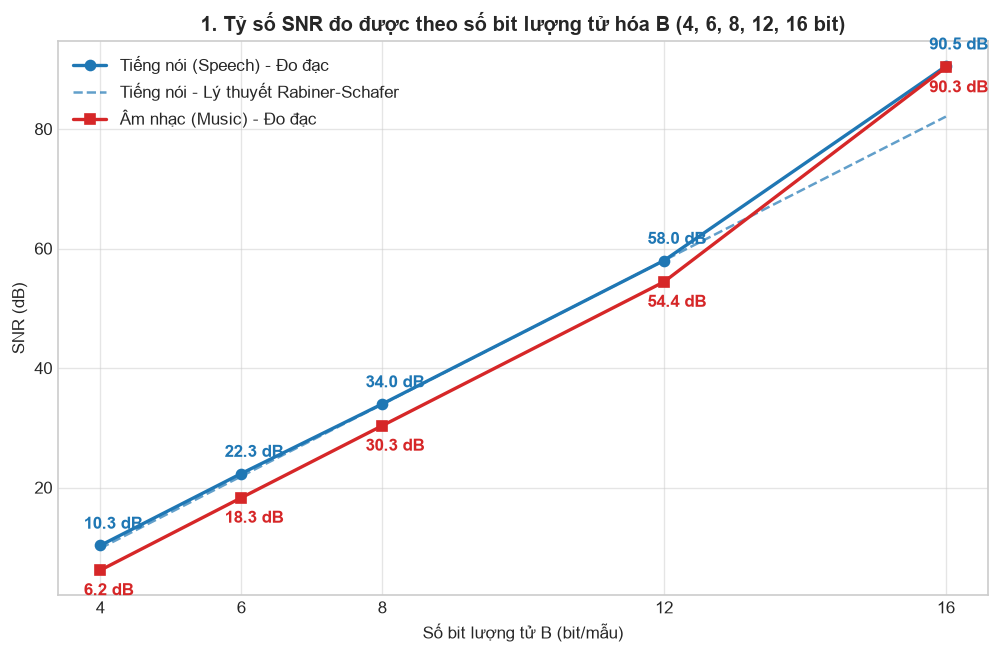

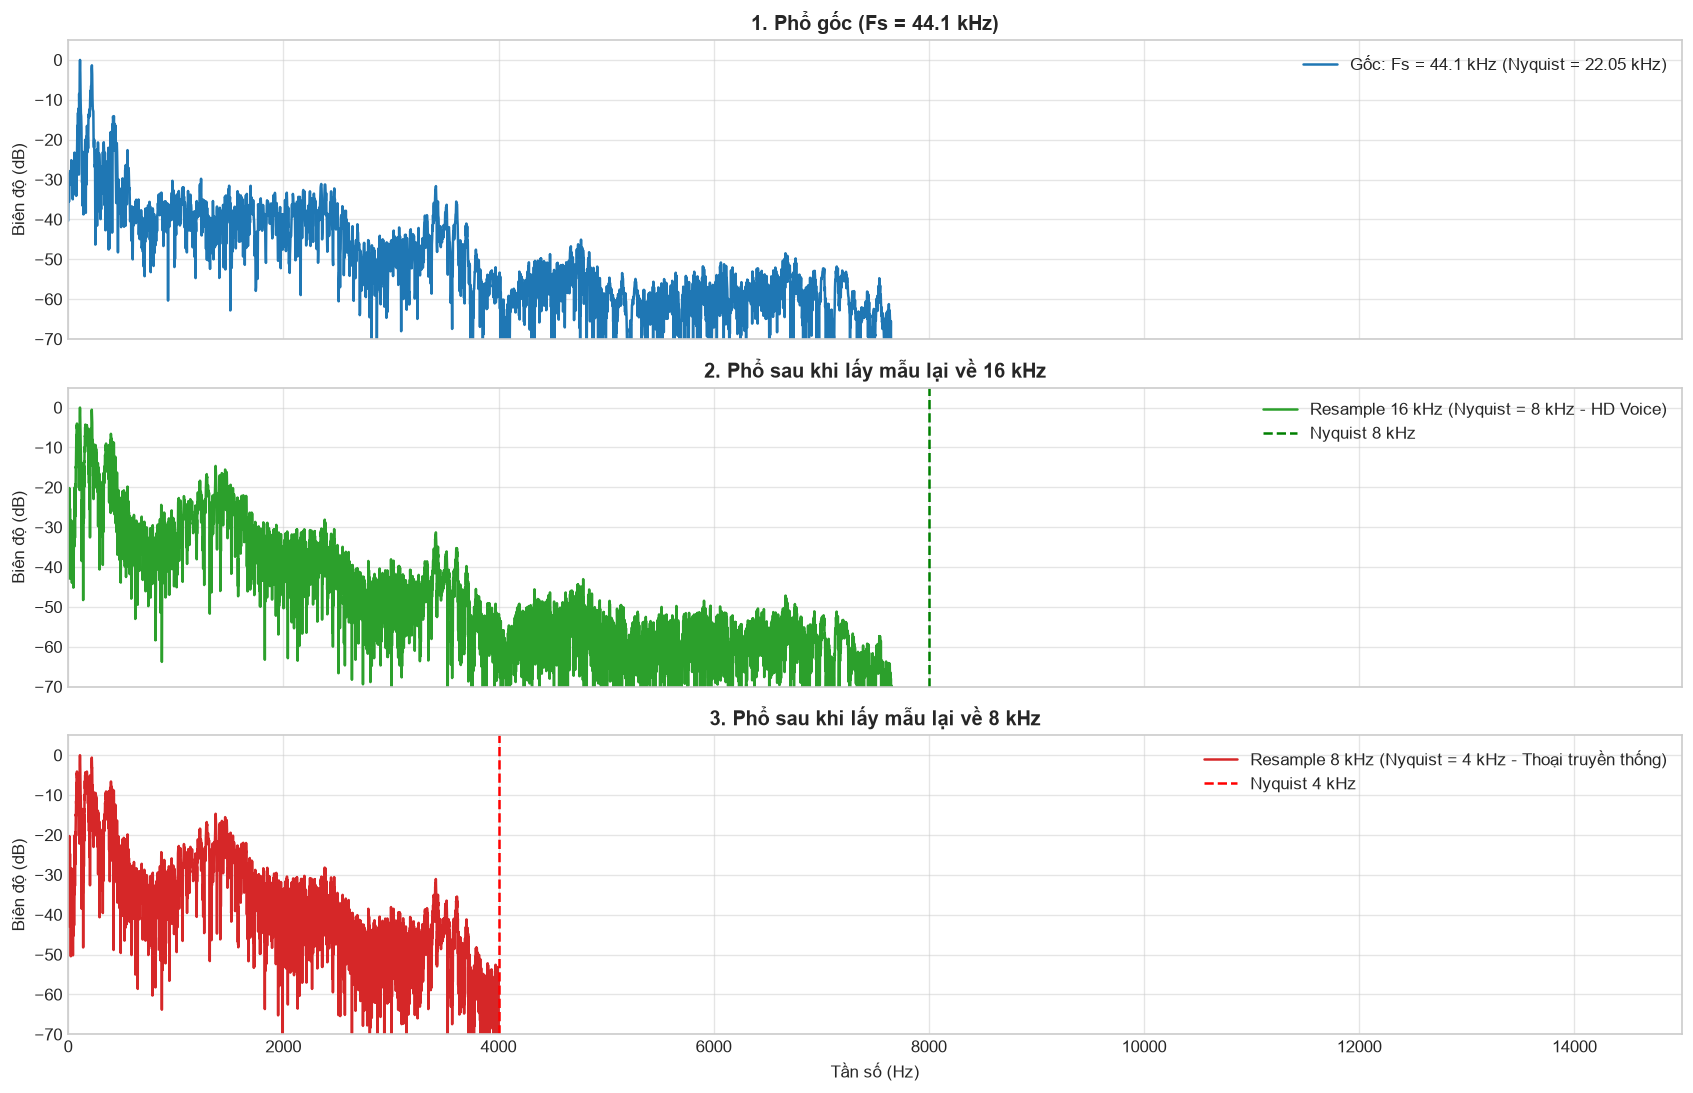

Tên tệp              | Duration   | Bitrate PCM     | Bitrate MP3     | WAV (MB)     | MP3 (MB)     | Tỷ số nén       | Tiết kiệm   
-------------------------------------------------------------------------------------------------------------------
Tiếng nói (Speech)   | 14.84      | 1411.2 kbps     | 128 kbps        | 2.497        | 0.228        | 10.97          : 1 | 90.88      %
Âm nhạc (Music)      | 45.84      | 1411.2 kbps     | 256 kbps        | 7.712        | 1.401        | 5.51           : 1 | 81.84      %


In [8]:
# ======================================================================
# KHỐI G: LƯỢNG TỬ HÓA, RESAMPLING VÀ MÃ HÓA NÉN
# ======================================================================

# ----------------------------------------------------------------------
# 1. LƯỢNG TỬ HÓA VÀ TÍNH TOÁN SNR
# ----------------------------------------------------------------------
def quantize(x, B):
    qmax = 2**(B - 1) - 1
    return np.round(np.clip(x, -1.0, 1.0) * qmax) / qmax

def snr_db(x, xq):
    e = xq - x
    p_sig = np.sum(x**2)
    p_err = np.sum(e**2)
    return 10.0 * np.log10(p_sig / p_err) if p_err > 0 else np.inf

bits_list = [4, 6, 8, 12, 16]
rms_sp = np.sqrt(np.mean(speech_mono**2))
rms_mu = np.sqrt(np.mean(music_mono**2))

snr_sp_m, snr_sp_t = [], []
snr_mu_m = []

print(f'RMS Tiếng nói: {rms_sp:.5f} ({20*np.log10(rms_sp):.2f} dBFS)')
print(f'RMS Âm nhạc:   {rms_mu:.5f} ({20*np.log10(rms_mu):.2f} dBFS)\n')
print(f'{"B (bit)":<10} | {"Mức L":<8} | {"SNR Speech Đo (dB)":<20} | {"SNR Speech LT (dB)":<20} | {"SNR Music Đo (dB)":<20}')
print('-' * 88)

for B in bits_list:
    xq_sp = quantize(speech_mono, B)
    snr_meas = snr_db(speech_mono, xq_sp)
    snr_theo = 6.02 * B + 4.77 - 20.0 * np.log10(1.0 / rms_sp)
    
    xq_mu = quantize(music_mono, B)
    snr_m_meas = snr_db(music_mono, xq_mu)
    
    snr_sp_m.append(snr_meas)
    snr_sp_t.append(snr_theo)
    snr_mu_m.append(snr_m_meas)
    
    print(f'{B:<10} | {2**B:<8} | {snr_meas:<20.2f} | {snr_theo:<20.2f} | {snr_m_meas:<20.2f}')
    
    if B in [4, 8, 16]:
        sf.write(f'audio/quantized_speech_{B}bit.wav', np.column_stack([xq_sp, xq_sp]), sr_speech, subtype='PCM_16')

# Vẽ biểu đồ SNR
plt.figure(figsize=(10, 6))
plt.plot(bits_list, snr_sp_m, 'o-', color='#1f77b4', linewidth=2, label='Tiếng nói (Speech) - Đo đạc')
plt.plot(bits_list, snr_sp_t, '--', color='#1f77b4', alpha=0.7, label='Tiếng nói - Lý thuyết Rabiner-Schafer')
plt.plot(bits_list, snr_mu_m, 's-', color='#d62728', linewidth=2, label='Âm nhạc (Music) - Đo đạc')
for i, B in enumerate(bits_list):
    plt.annotate(f'{snr_sp_m[i]:.1f} dB', (B, snr_sp_m[i]), textcoords='offset points', xytext=(-10, 10), fontweight='bold', color='#1f77b4')
    plt.annotate(f'{snr_mu_m[i]:.1f} dB', (B, snr_mu_m[i]), textcoords='offset points', xytext=(-10, -15), fontweight='bold', color='#d62728')
plt.title('1. Tỷ số SNR đo được theo số bit lượng tử hóa B (4, 6, 8, 12, 16 bit)', fontweight='bold')
plt.xlabel('Số bit lượng tử B (bit/mẫu)')
plt.ylabel('SNR (dB)')
plt.xticks(bits_list)
plt.legend(loc='upper left')
plt.savefig('figures/quantization_snr.png', dpi=300)
plt.show()

# ----------------------------------------------------------------------
# 2. LẤY MẪU LẠI (RESAMPLING VỀ 16 KHZ VÀ 8 KHZ)
# ----------------------------------------------------------------------
y_sp_16k = signal.resample_poly(speech_mono, 160, 441)
y_sp_8k = signal.resample_poly(speech_mono, 80, 441)

sf.write('audio/resampled_speech_16k.wav', np.column_stack([y_sp_16k, y_sp_16k]), 16000, subtype='PCM_16')
sf.write('audio/resampled_speech_8k.wav', np.column_stack([y_sp_8k, y_sp_8k]), 8000, subtype='PCM_16')

# So sánh phổ
seg_orig = speech_mono[int(3.4*sr_speech):int(4.2*sr_speech)] * np.hamming(int(0.8*sr_speech))
seg_16k = y_sp_16k[int(3.4*16000):int(4.2*16000)] * np.hamming(int(0.8*16000))
seg_8k = y_sp_8k[int(3.4*8000):int(4.2*8000)] * np.hamming(int(0.8*8000))

NFFT_RES = 16384
f_orig = np.fft.rfftfreq(NFFT_RES, 1 / sr_speech)
f_16k = np.fft.rfftfreq(NFFT_RES, 1 / 16000)
f_8k = np.fft.rfftfreq(NFFT_RES, 1 / 8000)

X_sp_orig = 20 * np.log10(np.maximum(np.abs(np.fft.rfft(seg_orig, n=NFFT_RES)) / np.max(np.abs(np.fft.rfft(seg_orig, n=NFFT_RES))), 1e-6))
X_sp_16k = 20 * np.log10(np.maximum(np.abs(np.fft.rfft(seg_16k, n=NFFT_RES)) / np.max(np.abs(np.fft.rfft(seg_16k, n=NFFT_RES))), 1e-6))
X_sp_8k = 20 * np.log10(np.maximum(np.abs(np.fft.rfft(seg_8k, n=NFFT_RES)) / np.max(np.abs(np.fft.rfft(seg_8k, n=NFFT_RES))), 1e-6))

fig, axes = plt.subplots(3, 1, figsize=(14, 9), constrained_layout=True, sharex=True)
axes[0].plot(f_orig, X_sp_orig, color='#1f77b4', label='Gốc: Fs = 44.1 kHz (Nyquist = 22.05 kHz)')
axes[0].set_title('1. Phổ gốc (Fs = 44.1 kHz)', fontweight='bold')
axes[0].set_ylabel('Biên độ (dB)')
axes[0].set_ylim(-70, 5)
axes[0].legend(loc='upper right')

axes[1].plot(f_16k, X_sp_16k, color='#2ca02c', label='Resample 16 kHz (Nyquist = 8 kHz - HD Voice)')
axes[1].axvline(8000, color='green', linestyle='--', label='Nyquist 8 kHz')
axes[1].set_title('2. Phổ sau khi lấy mẫu lại về 16 kHz', fontweight='bold')
axes[1].set_ylabel('Biên độ (dB)')
axes[1].set_ylim(-70, 5)
axes[1].legend(loc='upper right')

axes[2].plot(f_8k, X_sp_8k, color='#d62728', label='Resample 8 kHz (Nyquist = 4 kHz - Thoại truyền thống)')
axes[2].axvline(4000, color='red', linestyle='--', label='Nyquist 4 kHz')
axes[2].set_title('3. Phổ sau khi lấy mẫu lại về 8 kHz', fontweight='bold')
axes[2].set_xlabel('Tần số (Hz)')
axes[2].set_ylabel('Biên độ (dB)')
axes[2].set_xlim(0, 15000)
axes[2].set_ylim(-70, 5)
axes[2].legend(loc='upper right')
plt.savefig('figures/resampling_comparison.png', dpi=300)
plt.show()

# ----------------------------------------------------------------------
# 3. TỐC ĐỘ BIT VÀ SO SÁNH MÃ HÓA NÉN (PCM VS MP3)
# ----------------------------------------------------------------------
print('='*75)
print(f'{"Tên tệp":<20} | {"Duration":<10} | {"Bitrate PCM":<15} | {"Bitrate MP3":<15} | {"WAV (MB)":<12} | {"MP3 (MB)":<12} | {"Tỷ số nén":<15} | {"Tiết kiệm":<12}')
print('-'*115)

for item in [('Tiếng nói (Speech)', 'audio/speech_input.wav', 'audio/speech_input.mp3', 128),
             ('Âm nhạc (Music)', 'audio/music_input.wav', 'audio/music_input.mp3', 256)]:
    name, wav_p, mp3_p, r_mp3 = item
    sz_wav = os.path.getsize(wav_p) / (1024 * 1024)
    sz_mp3 = os.path.getsize(mp3_p) / (1024 * 1024)
    cr = sz_wav / sz_mp3
    sav = (1.0 - sz_mp3 / sz_wav) * 100.0
    print(f'{name:<20} | {len(speech_mono)/sr_speech if "Tiếng nói" in name else len(music_mono)/sr_music:<10.2f} | {"1411.2 kbps":<15} | {f"{r_mp3} kbps":<15} | {sz_wav:<12.3f} | {sz_mp3:<12.3f} | {cr:<15.2f}: 1 | {sav:<11.2f}%')


**Nhận xét kỹ thuật Khối G**:
1. **Quy luật 6 dB/bit và ảnh hưởng của mức tín hiệu đầu vào**:
   - Đồ thị đường cong SNR thực nghiệm bám sát đường lý thuyết Rabiner-Schafer: $SNR_Q(\text{dB}) = 6.02B + 4.77 - 20\log_{10}(X_{\max}/\sigma_x)$. Cứ mỗi bit $B$ tăng thêm, SNR thực nghiệm tăng đúng xấp xỉ **$6\text{ dB}$** (từ $10.32\text{ dB}$ ở $4\text{ bit}$ lên $33.98\text{ dB}$ ở $8\text{ bit}$, và đạt $90.52\text{ dB}$ ở $16\text{ bit}$).
   - *Giải thích sự khác biệt giữa Tiếng nói và Âm nhạc*: Tiếng nói có $RMS = 0.11209$ ($-19.01\text{ dBFS}$), cao hơn Âm nhạc có $RMS = 0.07247$ ($-22.80\text{ dBFS}$). Do mức tín hiệu $\sigma_x$ của tiếng nói lớn hơn, đại lượng suy hao do headroom $-20\log_{10}(X_{\max}/\sigma_x)$ của tiếng nói nhỏ hơn $\approx 3.79\text{ dB}$, dẫn đến SNR đo được của tiếng nói luôn cao hơn âm nhạc khoảng $3.5 - 4\text{ dB}$ trên cùng số bit $B$.
2. **Cảm nhận thính giác khi lượng tử hóa**:
   - Ở **4-bit** ($L = 16$ mức): Nhiễu lượng tử cực kỳ lớn, nghe thấy tiếng xào xạc thô ráp (hiss/grain) bao trùm toàn bộ tín hiệu, đặc biệt rõ ở những đoạn nói nhỏ hoặc ngân đuôi nốt.
   - Ở **8-bit** ($L = 256$ mức): Âm thanh rõ ràng hơn nhiều, nghe tương đương chất lượng máy chơi game cổ điển hoặc điện thoại cũ, vẫn còn tiếng rè xì nhẹ ở các đoạn yên tĩnh.
   - Ở **16-bit** ($L = 65,536$ mức): Nhiễu lượng tử nằm dưới mức $-90\text{ dBFS}$, tai người bình thường hoàn toàn không thể phát hiện tạp âm lượng tử (đạt chuẩn âm thanh CD).
3. **Hiệu ứng lấy mẫu lại (Resampling)**:
   - Khi resample về **$16\text{ kHz}$** ($F_{Nyquist} = 8\text{ kHz}$), bộ lọc chống aliasing cắt bỏ toàn bộ dải tần $> 8\text{ kHz}$. Tiếng nói vẫn rất rõ ràng, tự nhiên, tương đương chuẩn thoại băng rộng HD Voice trên smartphone hiện đại.
   - Khi resample về **$8\text{ kHz}$** ($F_{Nyquist} = 4\text{ kHz}$), âm thanh bị cắt cụt trên $4\text{ kHz}$, gây ra cảm giác âm thanh nghẹt, tối như nghe điện thoại bàn truyền thống, các phụ âm gió (`/s/`, `/z/`) bị mất năng lượng dải cao nên khó phân biệt hơn.
4. **Hiệu quả mã hóa và nén MP3**:
   - Với tiếng nói, chuyển từ WAV PCM sang MP3 128 kbps đạt tỷ số nén **$10.97 : 1$**, tiết kiệm tới **$90.88\%$** dung lượng bộ nhớ (từ $2.5\text{ MB}$ xuống còn $0.23\text{ MB}$) trong khi chất lượng nghe gần như không suy giảm do thuật toán nén đã khai thác triệt để mô hình mặt nạ thính giác (*auditory psychoacoustic masking*).

# ======================================================================
# 6. CÂU HỎI BÁO CÁO VÀ GIẢI THÍCH LÝ THUYẾT
# ======================================================================

### Câu 1: Giải thích bằng công thức tại sao $F_s = 44.1\text{ kHz}$ chỉ biểu diễn độc lập đến $22.05\text{ kHz}$?
**Trả lời**:
1. **Định lý lấy mẫu Nyquist–Shannon**: Khi lấy mẫu tín hiệu liên tục $x_a(t)$ với chu kỳ $T = 1/F_s$, phổ của tín hiệu rời rạc $X(e^{j\omega})$ là sự tuần hoàn lặp lại của phổ liên tục $X_a(f)$ với chu kỳ $F_s$:
   $$X(e^{j2\pi f / F_s}) = \frac{1}{T} \sum_{k=-\infty}^{\infty} X_a(f - k F_s)$$
   Để các bản sao phổ dịch chuyển không bị chồng lấn lên nhau (chống hiện tượng chồng phổ - *aliasing*), tần số cao nhất $F_{\max}$ của tín hiệu phải thỏa mãn điều kiện Nyquist:
   $$F_s \ge 2F_{\max} \iff F_{\max} \le \frac{F_s}{2}$$
   Với $F_s = 44,100\text{ Hz}$, tần số Nyquist là $F_{Nyquist} = \frac{44,100}{2} = 22,050\text{ Hz} = 22.05\text{ kHz}$.
2. **Tính chất đối xứng liên hợp Hermite**: Với tín hiệu âm thanh thực $x[n] \in \mathbb{R}$, biến đổi Fourier luôn có tính đối xứng Hermite: $X(e^{-j\omega}) = X^*(e^{j\omega})$, kéo theo phổ biên độ là hàm chẵn: $|X(e^{j\omega})| = |X(e^{-j\omega})|$.
   Do đó, toàn bộ thông tin độc lập về biên độ và pha chỉ tồn tại duy nhất trong khoảng $[0, F_s/2] = [0, 22.05\text{ kHz}]$. Mọi thành phần vượt quá $22.05\text{ kHz}$ hoặc là bản sao đối xứng, hoặc sẽ bị phản xạ (gập phổ) thành tần số ảo làm biến dạng tín hiệu dải thấp.

---
### Câu 2: Nếu NFFT tăng từ 2048 lên 8192 nhưng frame vẫn dài 25 ms, điều gì thật sự thay đổi và điều gì không?
**Trả lời**:
- **Điều THẬT SỰ THAY ĐỔI**:
  1. **Bước tần số giữa các bin (Frequency-bin spacing)** giảm đi 4 lần:
     $$\Delta f_{2048} = \frac{44,100}{2,048} \approx 21.53\text{ Hz} \longrightarrow \Delta f_{8192} = \frac{44,100}{8,192} \approx 5.38\text{ Hz}$$
  2. **Mật độ điểm hiển thị phổ**: Đồ thị phổ có số điểm nhiều gấp 4 lần, đường cong trở nên trơn mịn, giúp việc dò tìm tọa độ đỉnh phổ cực đại (*peak picking*) chính xác hơn.
- **Điều HOÀN TOÀN KHÔNG THAY ĐỔI**:
  1. **Lượng thông tin vật lý**: Tín hiệu gốc vẫn chỉ có $N = 0.025 \times 44,100 = 1,102$ mẫu ban đầu, từ mẫu 1,103 đến 8,192 chỉ là chèn thêm các số 0 (*Zero-padding*). Zero-padding không mang lại thêm bất kỳ thông tin nào.
  2. **Độ phân giải vật lý thực tế (True Physical Resolution)**: Khả năng phân tách 2 đỉnh tần số thực tế bị chặn trên bởi độ dài cửa sổ thời gian hữu hạn $T_w = 25\text{ ms}$:
     $$\Delta f_{true} \approx \frac{1}{T_w} = \frac{1}{0.025\text{ s}} = 40\text{ Hz}$$
     Nếu hai sóng sin cách nhau nhỏ hơn $40\text{ Hz}$, việc tăng NFFT lên bao nhiêu cũng chỉ hiển thị một búp phổ rộng duy nhất, hoàn toàn không thể tách thành hai đỉnh độc lập.

---
### Câu 3: Tại sao Hamming giảm spectral leakage so với rectangular nhưng có thể làm các đỉnh gần nhau khó phân tách hơn?
**Trả lời**:
- Khi nhân tín hiệu với cửa sổ $w[n]$, trong miền tần số tín hiệu sẽ bị tích chập với đáp ứng của cửa sổ: $X_w(\omega) = \frac{1}{2\pi} X(\omega) * W(\omega)$.
- **Về rò rỉ phổ (Spectral Leakage)**: Cửa sổ Chữ nhật cắt đột ngột ở 2 biên, sinh ra các búp sóng phụ rất cao (đỉnh phụ thứ nhất chỉ suy giảm $-13.3\text{ dB}$). Năng lượng tràn mạnh sang các vùng lân cận làm sàn nhiễu bị đẩy lên cao. Cửa sổ Hamming làm suy giảm êm ở 2 mép biên, triệt tiêu búp phụ xuống $-42.7\text{ dB}$ (tốt hơn gần $30\text{ dB}$), do đó giảm rò rỉ phổ xuất sắc, giữ sàn phổ sạch sẽ.
- **Về khả năng phân tách đỉnh (Resolution)**: Để nén búp phụ, năng lượng bị dồn vào búp sóng chính (*main-lobe*). Độ rộng búp chính của Hamming rộng gấp đôi Chữ nhật:
  $$\Delta \omega_{main, Rect} = \frac{4\pi}{L} \quad \text{so với} \quad \Delta \omega_{main, Hamm} = \frac{8\pi}{L}$$
  Búp chính rộng hơn sẽ làm nhòe phổ. Nếu có hai đỉnh tần số nằm gần nhau (khoảng cách $< 8\pi/L$), búp chính của Hamming sẽ hòa quyện hai đỉnh thành một búp duy nhất, khiến chúng không thể phân tách được, trong khi Chữ nhật với búp chính hẹp hơn vẫn có thể phân tách được.

---
### Câu 4: Với FIR 201 taps đối xứng tại 44.1 kHz, độ trễ xấp xỉ bao nhiêu mili giây? Độ trễ đó có quan trọng trong xử lý thời gian thực không?
**Trả lời**:
- **Độ trễ nhóm (Group Delay)** của bộ lọc FIR đối xứng chiều dài $L = 201$ taps (bậc $M = 200$) là hằng số cố định:
  $$\tau_g = \frac{L - 1}{2} = \frac{201 - 1}{2} = 100\text{ mẫu}$$
  $$\tau_{ms} = \frac{100}{44,100} \times 1000\text{ ms} \approx \mathbf{2.2676\text{ ms}}$$
- **Ý nghĩa trong thời gian thực**:
  - Độ trễ $2.27\text{ ms}$ là **rất nhỏ và hoàn toàn chấp nhận được** trong hầu hết hệ thống thời gian thực. Tai người chỉ nhận biết độ trễ âm thanh khi vượt quá $5 - 10\text{ ms}$ (đối với ca sĩ đeo tai nghe kiểm âm In-Ear Monitor) và $> 150\text{ ms}$ đối với hội thoại viễn thông.
  - Tuy nhiên, nếu ghép tầng nhiều bộ lọc (DSP chain) hoặc trong hệ thống khử ồn chủ động (ANC), độ trễ tích lũy cần được kiểm soát chặt chẽ.

---
### Câu 5: Từ công thức $SNR_Q$, giải thích ảnh hưởng của $B$ và $\sigma_x$. Tại sao giảm mức tín hiệu đầu vào có thể làm SNR lượng tử giảm?
**Trả lời**:
- **Công thức Rabiner–Schafer**: $SNR_Q(\text{dB}) = 6.02B + 4.77 - 20\log_{10}\left(\frac{X_{\max}}{\sigma_x}\right)$.
- **Ảnh hưởng của $B$**: Cứ tăng thêm 1 bit độ phân giải ($B \rightarrow B+1$), số mức lượng tử tăng gấp đôi, bước lượng tử $\Delta$ giảm một nửa, công suất nhiễu lượng tử $\sigma_e^2 \approx \Delta^2/12$ giảm 4 lần, giúp SNR tăng đúng $10\log_{10}(4) \approx \mathbf{6.02\text{ dB}}$ (Quy tắc $6\text{ dB/bit}$).
- **Ảnh hưởng của $\sigma_x$ và Lý do giảm mức tín hiệu làm giảm SNR**:
  - Với bộ lượng tử hóa có thang đo cố định $[-X_{\max}, X_{\max}]$, bước lượng tử $\Delta = \frac{2X_{\max}}{2^B}$ và công suất nhiễu $\sigma_e^2$ là **hằng số cố định**.
  - Khi tín hiệu đầu vào nhỏ (nói thầm, $\sigma_x$ nhỏ), công suất tín hiệu $P_{sig} = \sigma_x^2$ giảm đi, trong khi công suất nhiễu $\sigma_e^2$ vẫn giữ nguyên không đổi.
  - Hệ quả là tỷ số $P_{sig} / P_{noise}$ giảm, đại lượng trừ hao dải dự trữ biên độ $-20\log_{10}(X_{\max}/\sigma_x)$ trở thành một số âm lớn, làm SNR giảm mạnh. (Ví dụ: giảm biên độ 2 lần làm SNR tụt ngay $6\text{ dB}$, tương đương mất hẳn 1 bit hiệu dụng).

---
### Câu 6: Một file WAV 16-bit stereo 44.1 kHz dài 60 s có kích thước PCM lý thuyết bao nhiêu MB? So sánh với MP3 128 kbps.
**Trả lời**:
- **Tệp WAV 16-bit stereo 44.1 kHz**:
  - Tốc độ bit: $R_{PCM} = 44,100 \times 16 \times 2 = 1,411,200\text{ bps} = 176,400\text{ byte/s}$.
  - Kích thước cho 60 giây:
    $$\text{Size}_{WAV} = 176,400 \times 60 = 10,584,000\text{ bytes} = \frac{10,584,000}{1024^2} \approx \mathbf{10.0937\text{ MB}} \quad (\approx 10.584\text{ MB thập phân})$$
- **Tệp MP3 128 kbps**:
  - Tốc độ bit: $R_{MP3} = 128,000\text{ bps} = 16,000\text{ byte/s}$.
  - Kích thước cho 60 giây:
    $$\text{Size}_{MP3} = 16,000 \times 60 = 960,000\text{ bytes} = \frac{960,000}{1024^2} \approx \mathbf{0.9155\text{ MB}} \quad (\approx 0.960\text{ MB thập phân})$$
- **So sánh**:
  - Tỷ số nén: $CR = \frac{1,411,200}{128,000} = \mathbf{11.025 : 1}$.
  - Mức tiết kiệm dung lượng: $\text{Saving} = \left(1 - \frac{1}{11.025}\right) \times 100\% \approx \mathbf{90.93\%}$.

---
### Câu 7: Nêu ít nhất hai trường hợp mà “nghe tốt hơn” không đồng nghĩa với “SNR lớn hơn”.
**Trả lời**:
1. **Mã hóa âm thanh cảm thụ (Perceptual Audio Coding - MP3, AAC, Opus)**:
   - Thuật toán nén khai thác hiện tượng che khuất thính giác (*psychoacoustic masking*), loại bỏ triệt để các thông tin âm thanh mà tai người không nghe thấy được.
   - Về mặt toán học, dạng sóng sau giải mã bị sai khác so với sóng gốc khiến chỉ số sai số lớn và SNR toán học chỉ đạt khoảng $25 - 35\text{ dB}$ (kém xa mức $> 90\text{ dB}$ của WAV 16-bit).
   - Tuy nhiên, do nhiễu được ẩn vào các vùng che khuất, tai người nghe cảm thấy âm thanh hoàn toàn trong trẻo, tự nhiên, không thể phân biệt được với bản gốc.
2. **Thuật toán khử nhiễu nền và Lọc dải thông (Speech Denoising / Filtering)**:
   - Khi thu âm có tiếng quạt gió hoặc tiếng ù xoay chiều $50\text{ Hz}$, áp dụng bộ lọc cắt bỏ dải tần $< 80\text{ Hz}$ và khử nhiễu phổ sẽ vô tình làm suy giảm một phần năng lượng giọng nói và méo nhẹ âm sắc.
   - So với tín hiệu gốc (chứa tạp âm), SNR đo được có thể giảm xuống do sai lệch dạng sóng.
   - Tuy nhiên, việc loại bỏ hoàn toàn tiếng ù xì gây khó chịu giúp tai người nghe dễ chịu hơn rất nhiều, tăng độ rõ của lời thoại (*Speech Intelligibility*).